In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.animation import FuncAnimation

<a id="intro"></a>
# 1. Introductie en Specificaties
## 1.1 Nokken-ontwerp: specificaties
Gegevens : De te ontwerpen nok moet volgende heffing kunnen realiseren :

1. van 45° tot 90° : +5 mm
2. van 90° tot 180° : +15 mm
3. van 180° tot 305° : -20 mm

De equivalente massa en dempingsconstante van de volger (en bijhorende onderdelen) worden respectievelijk geschat op 15 kg en 0.055, terwijl het mechanisme volgende statische krachten moet uitoefenen:

1. van 45° tot 90° : een konstante druk-kracht van 250 N
2. van 90° tot 180° : een lineair toenemende druk-kracht van 250 N tot 1050 N
3. van 180° tot 250° : een konstante trek-kracht van 300 N

De gevraagde cyclustijd voor de bewerking uitgevoerd door de volger is 0.3 sec.

Hieronder tonen we de gegeven specs in een grafiek van de positie en de kracht

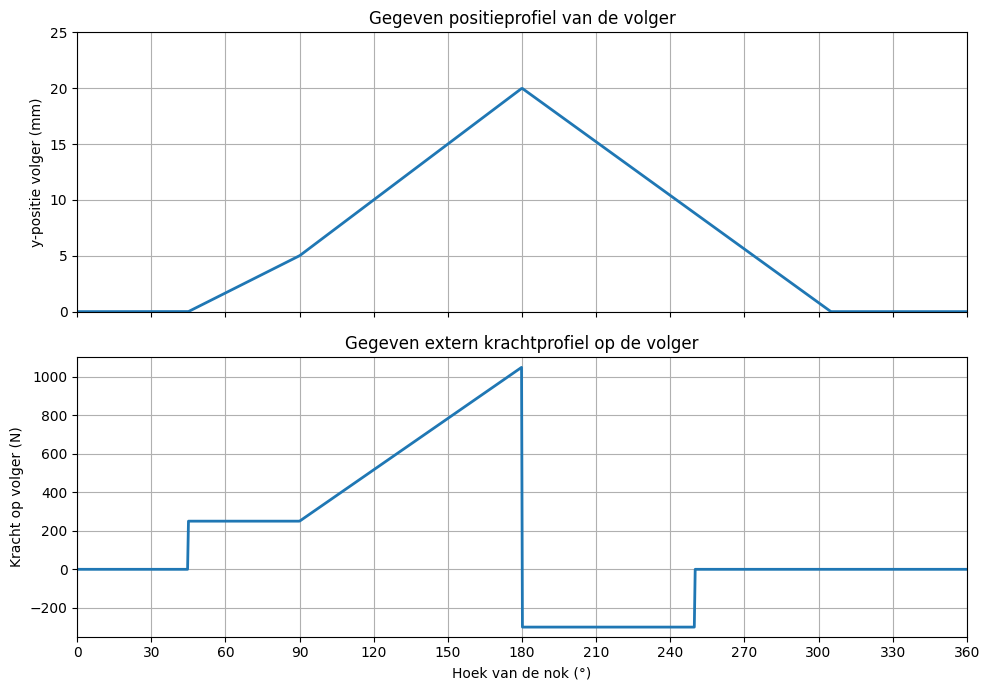

In [ ]:
"""
Gegeven specificaties
"""

theta = np.linspace(0, 360, 1000)   # hoek van de nok °

F_pre = 250    #N
F_max = 1050   #N
F_pull = -300  #N

theta_pull_end = 250 #°

"""
Positieprofiel y(theta)
"""
y = np.zeros_like(theta)

# 45°-90°: 0mm - 5mm
mask = (theta >= 45) & (theta < 90)
y[mask] = (theta[mask] - 45) / (90 - 45) * 5

# 90°-180°: 5mm - 20mm
mask = (theta >= 90) & (theta < 180)
y[mask] = 5 + (theta[mask] - 90) / (180 - 90) * 15

# 180°-305°: van 20mm - 0mm
mask = (theta >= 180) & (theta < 305)
y[mask] = 20 - (theta[mask] - 180) / (305 - 180) * 20

# 0°-45° en 305°-360° blijven 0mm

"""
Externe kracht F(theta)
"""
F = np.zeros_like(theta)

# 45° - 90°: cte drukkracht
mask = (theta >= 45) & (theta < 90)
F[mask] = F_pre

# 90° - 180°: lineair stijgend van F_pre naar F_max
mask = (theta >= 90) & (theta < 180)
F[mask] = F_pre + (theta[mask] - 90) / (180 - 90) * (F_max - F_pre)

# 180° - theta_pull_end: cte trekkracht
mask = (theta >= 180) & (theta < theta_pull_end)
F[mask] = F_pull

# Na theta_pull_end blijft de kracht 0 N

"""
# Grafieken
"""
fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Grafiek 1: positie
axs[0].plot(theta, y, linewidth=2)
axs[0].set_ylabel("y-positie volger (mm)")
axs[0].set_title("Gegeven positieprofiel van de volger")
axs[0].set_xlim(0, 360)
axs[0].set_ylim(0, 25)
axs[0].set_yticks(np.arange(0, 26, 5))
axs[0].grid(True)

# Grafiek 2: kracht
axs[1].plot(theta, F, linewidth=2)
axs[1].set_xlabel("Hoek van de nok (°)")
axs[1].set_ylabel("Kracht op volger (N)")
axs[1].set_title("Gegeven extern krachtprofiel op de volger")
axs[1].set_xlim(0, 360)
axs[1].set_ylim(-350, 1100)
axs[1].set_xticks(np.arange(0, 361, 30))
axs[1].grid(True)

plt.tight_layout()
plt.show()

# 1.2: Toepassing - Tablet Press

Op basis van het krachtenprofiel dachten we een soort stempelmachine te maken. Dit past goed bij een nokmechanisme, omdat de gewenste beweging periodiek is en omdat de kracht sterk afhankelijk is van de positie van de stempel .Omdat de krachten niet ongelofelijk hoog zijn was de toepassing tablet press voor de farmaseutische industrie boven gekomen. Hieronder is een schets van de verschillende stappen met daaronder uitleg.

<p align="center">
  <img src="Images\visualisatie_compressie.png" width="700"><br>
  <b>Figuur 1:</b> Visualie compressiestappen
</p>

#### Positie 1: Rust
**Hoeken: 305°-45°**

De stempel blijft zijn positie houden en ondervind geen externe krachten. Tijdens deze fase wordt de afgemaakte pil afgevoerd en een nieuwe matrijs gevuld met poeder klaargezet voor de volgende compressie.

#### Positie 2: Plaatsing stempel
**Hoek: $\theta_1$**

De stempel in rust is 2.5mm verwijderd van de opening van de matrijs. Van positie 1 naar positie 2 verplaatst de stempel dus +2.5mm zonder kracht te ondervinden. De reden dat deze hoek $\theta_1$ wordt genoemd is omdat uiteindelijk het verplaatsingsprofiel wordt verzacht om minder sterke schokken te krijgen (deze moet dus berekend worden).

#### Positie 3: Indrukken stempel
**Hoek: 90°**

De stempel positioneert zich 2.5mm in de matrijs (afmaken van 5mm verplaatsing). Binnen de matrijs in de neerwaarste slag zal de stempel een constante tegenwerkende wrijving ([1]) van 250N ondervinden (daarom dat van 1 $\rightarrow$ 3 opgesplitst moest worden). De kleine compressie van de poeder die hier gebeurt wordt verwaarloosd.

#### Positie 4: Compressie + Dwell
**Hoeken: 150°-180°**

Van 90°-150° is de compressieslag van de stempel waar de stempel 15mm in de matrijs wordt geduwd. Compressie wordt gemodelleerd als evenredig met de samendrukking en dus lineair toenemend tot 1050N. Hierbovenop wordt de wrijving in de matrijs gesuperponeerd.

Van 150°-180° blijft de stempel op dezelfde positie. Dit heet dwelling en zorgt ervoor dat er minder kans is op barsten in de pil ([2],[3]). In deze positie ondervind de stempel altijd dezelfde kracht van 1050N.

#### Positie 5: Uittrekken
**Hoek: $\theta_2$**

Van 180°-$\theta_2$ wordt de stempel 17.5mm uitgetrokken. Op deze positie is de stempel net uit de matrijs en tot dan ondervindt het een tegenwerkende kracht van -300N.

#### Positie 6: Terug naar startpositie
**Hoek: 305°**

De stempel verplaatst de laatste 2.5mm terug naar de startpositie. Tijdens deze beweging ondervindt de stempel geen uitwendige kracht.

### Verschillen met gegeven positie- en krachtprofielen:
Ten opzichte van de oorspronkelijke specificatie voegen we dus vooral een duidelijkere compressiefase en een dwell op maximale lift toe. Hierdoor sluit het bewegingsprofiel beter aan bij de gekozen toepassing.

### Vergelijking met commerciele tablet press:
[4], [5]

<div style="display: flex; justify-content: center; margin-top: 1rem;">
    <img src="Images/Tablet_press_animation.gif"
         style="max-width: 600px; width: 100%; height: auto; border: 0;" />
</div>


## Keuze van de bewegingswetten

Voor de vrije verplaatsing en de eerste intrede in de matrijs wordt een cycloïdale bewegingswet gebruikt. Deze bewegingswet heeft een nulwaarde voor snelheid en versnelling aan het begin en einde van het segment. Daardoor wordt de overgang tussen rust en beweging vloeiender dan bij een lineair profiel. Dit is belangrijk omdat plotse versnellingen trillingen kunnen veroorzaken, wat nadelig is voor een gelijkmatige poederverdeling in de matrijs.

Voor de hoofdcompressie wordt een 7de-graads polynoom gebruikt. Dit segment is het meest kritisch, omdat hier de grootste krachten optreden en de tablet effectief gevormd wordt. De 7de-graads polynoom zorgt ervoor dat positie, snelheid, versnelling en jerk op een gecontroleerde manier naar nul kunnen gaan aan de grenzen van het segment. Hierdoor worden schokken en abrupte veranderingen in de dynamische belasting beperkt.

Tussen 150° en 180° wordt een dwell voorzien. Tijdens deze fase blijft de stempel op maximale indrukking staan. Dit laat toe om de maximale compressiekracht gedurende een korte tijd aan te houden, wat de kwaliteit en vormvastheid van de tablet kan verbeteren.

Voor de terugtrekkende beweging wordt opnieuw een cycloïdale bewegingswet gebruikt. Deze beweging is minder kritisch dan de hoofdcompressie, maar moet nog steeds voldoende vloeiend verlopen om beschadiging van de gevormde tablet te vermijden. De laatste verplaatsing terug naar de startpositie gebeurt opnieuw zonder externe kracht.

In [3]:
# ---------------------------------------------------------
# Specificaties toepassing: tablet press
# ---------------------------------------------------------

dtheta = 0.01          # resolutie in graden
T = 0.3                # cyclustijd in s
omega = 2 * np.pi / T  # hoeksnelheid in rad/s

theta_deg = np.arange(0, 360, dtheta)   # hoek in graden
theta = theta_deg * np.pi / 180         # hoek in radialen

lift = np.zeros_like(theta_deg)         # y-positie [mm]
vel_deg = np.zeros_like(theta_deg)      # dy/dtheta [mm/deg]
acc_deg = np.zeros_like(theta_deg)      # d²y/dtheta² [mm/deg²]
jerk_deg = np.zeros_like(theta_deg)     # d³y/dtheta³ [mm/deg³]
ext_load = np.zeros_like(theta_deg)     # externe kracht [N]
pressure_angle = np.zeros_like(theta_deg)


# ---------------------------------------------------------
# Bewegingswetten
# ---------------------------------------------------------

def motion_law(u, law):
    """
    Geeft dimensieloze positie q, snelheid dq, versnelling ddq en jerk dddq
    als functie van u = (theta - theta_start) / beta.
    De afgeleiden zijn naar u, niet naar theta.
    """

    if law == 1:  # dwell
        q = np.zeros_like(u)
        dq = np.zeros_like(u)
        ddq = np.zeros_like(u)
        dddq = np.zeros_like(u)

    elif law == 6:  # cycloïde
        q = u - np.sin(2 * np.pi * u) / (2 * np.pi)
        dq = 1 - np.cos(2 * np.pi * u)
        ddq = 2 * np.pi * np.sin(2 * np.pi * u)
        dddq = 4 * np.pi**2 * np.cos(2 * np.pi * u)

    elif law == 7:  # 5de-graads polynoom
        q = 10*u**3 - 15*u**4 + 6*u**5
        dq = 30*u**2 - 60*u**3 + 30*u**4
        ddq = 60*u - 180*u**2 + 120*u**3
        dddq = 60 - 360*u + 360*u**2

    elif law == 9:  # 7de-graads polynoom
        q = 35*u**4 - 84*u**5 + 70*u**6 - 20*u**7
        dq = 140*u**3 - 420*u**4 + 420*u**5 - 140*u**6
        ddq = 420*u**2 - 1680*u**3 + 2100*u**4 - 840*u**5
        dddq = 840*u - 5040*u**2 + 8400*u**3 - 4200*u**4

    else:
        raise ValueError(f"Onbekende bewegingswet: {law}")

    return q, dq, ddq, dddq


def add_motion_segment(startangle, endangle, startlift, endlift, motionlaw):
    """
    Vult lift, vel_deg, acc_deg en jerk_deg voor één bewegingssegment.
    De globale variabelen blijven zo bruikbaar in de rest van de notebook.
    """

    assert endangle > startangle, "End angle should be bigger than start angle"

    mask = (theta_deg >= startangle) & (theta_deg < endangle)

    beta = endangle - startangle
    L = endlift - startlift

    u = (theta_deg[mask] - startangle) / beta
    q, dq, ddq, dddq = motion_law(u, motionlaw)

    lift[mask] = startlift + L * q
    vel_deg[mask] = L / beta * dq
    acc_deg[mask] = L / beta**2 * ddq
    jerk_deg[mask] = L / beta**3 * dddq


def find_theta_at_lift(startangle, endangle, target_lift):
    """
    Zoekt de hoek waarbij de lift in een segment target_lift bereikt.
    Werkt zowel voor stijgende als dalende beweging.
    """

    mask = (theta_deg >= startangle) & (theta_deg < endangle)

    th = theta_deg[mask]
    y = lift[mask]

    crossings = np.where((y[:-1] - target_lift) * (y[1:] - target_lift) <= 0)[0]

    if len(crossings) == 0:
        raise ValueError(
            f"Lift {target_lift} mm wordt niet bereikt tussen {startangle}° en {endangle}°"
        )

    i = crossings[0]

    # lineaire interpolatie tussen twee dichtstbijzijnde punten
    theta_crossing = th[i] + (target_lift - y[i]) * (th[i+1] - th[i]) / (y[i+1] - y[i])

    return theta_crossing

In [4]:
# ---------------------------------------------------------
# Segmenten van het aangepaste positieprofiel
# ---------------------------------------------------------

startangle1 = 0
endangle1 = 45
theta_seg1 = endangle1 - startangle1
startlift1 = 0
endlift1 = 0
motionlaw1 = 1      # dwell


startangle2 = 45
endangle2 = 90
theta_seg2 = endangle2 - startangle2
startlift2 = 0
endlift2 = 5
motionlaw2 = 6      # cycloïde


startangle3 = 90
endangle3 = 150
theta_seg3 = endangle3 - startangle3
startlift3 = 5
endlift3 = 20
motionlaw3 = 9      # 7de-graads polynoom


startangle4 = 150
endangle4 = 180
theta_seg4 = endangle4 - startangle4
startlift4 = 20
endlift4 = 20
motionlaw4 = 1      # dwell


startangle5 = 180
endangle5 = 305
theta_seg5 = endangle5 - startangle5
startlift5 = 20
endlift5 = 0
motionlaw5 = 6      # cycloïde


startangle6 = 305
endangle6 = 360
theta_seg6 = endangle6 - startangle6
startlift6 = 0
endlift6 = 0
motionlaw6 = 1      # dwell


motion_segments = [
    (startangle1, endangle1, startlift1, endlift1, motionlaw1),
    (startangle2, endangle2, startlift2, endlift2, motionlaw2),
    (startangle3, endangle3, startlift3, endlift3, motionlaw3),
    (startangle4, endangle4, startlift4, endlift4, motionlaw4),
    (startangle5, endangle5, startlift5, endlift5, motionlaw5),
    (startangle6, endangle6, startlift6, endlift6, motionlaw6),
]

for segment in motion_segments:
    add_motion_segment(*segment)


# Oude conventie uit jullie notebook: afgeleiden naar radialen
vel = vel_deg * 180 / np.pi
acc = acc_deg * (180 / np.pi)**2
jerk = jerk_deg * (180 / np.pi)**3

# Extra: echte tijdsafgeleiden, handig voor interpretatie en dynamica
vel_time = vel * omega
acc_time = acc * omega**2
jerk_time = jerk * omega**3

In [5]:
# ---------------------------------------------------------
# Bepaal theta1 en theta2 uit het gesmoothde positieprofiel
# ---------------------------------------------------------

# theta1: stempel raakt de opening van de matrijs bij y = 2.5 mm
theta1 = find_theta_at_lift(45, 90, 2.5)

# theta2: stempel is opnieuw net uit de matrijs bij y = 2.5 mm
theta2 = find_theta_at_lift(180, 305, 2.5)

print(f"theta1 = {theta1:.2f}°")
print(f"theta2 = {theta2:.2f}°")

theta1 = 67.50°
theta2 = 269.86°


In [6]:
# ---------------------------------------------------------
# Aangepast krachtenprofiel
# ---------------------------------------------------------

def add_load_segment(startangle, endangle, startload, endload):
    """
    Vult ext_load voor één krachtsegment.
    Kracht verloopt lineair van startload naar endload.
    """

    if np.isclose(startangle, endangle):
        return

    mask = (theta_deg >= startangle) & (theta_deg < endangle)

    u = (theta_deg[mask] - startangle) / (endangle - startangle)
    ext_load[mask] = startload + u * (endload - startload)


# Van 45° tot theta1: geen externe kracht,
# want de stempel beweegt nog vrij naar de opening van de matrijs.

startangleload1 = theta1
endangleload1 = 90
startload1 = 250
endload1 = 250


startangleload2 = 90
endangleload2 = 150
startload2 = 250
endload2 = 1050


startangleload3 = 150
endangleload3 = 180
startload3 = 1050
endload3 = 1050


startangleload4 = 180
endangleload4 = theta2
startload4 = -300
endload4 = -300


load_segments = [
    (startangleload1, endangleload1, startload1, endload1),
    (startangleload2, endangleload2, startload2, endload2),
    (startangleload3, endangleload3, startload3, endload3),
    (startangleload4, endangleload4, startload4, endload4),
]

for segment in load_segments:
    add_load_segment(*segment)

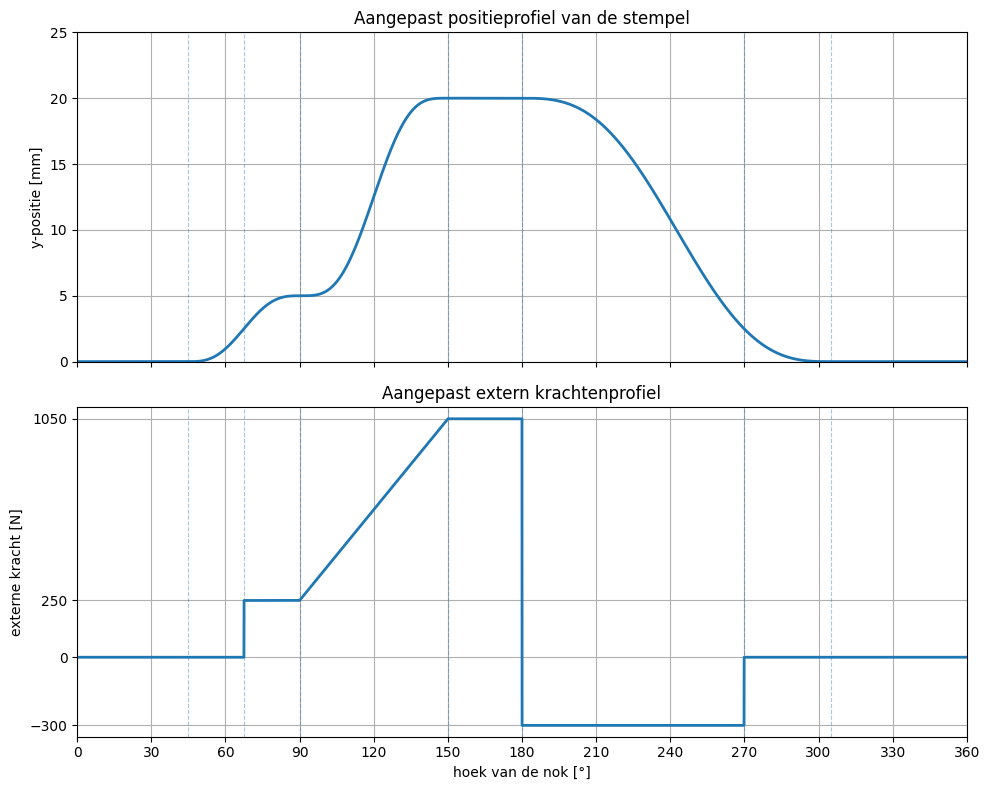

In [7]:
# ---------------------------------------------------------
# Gealigneerde grafieken: positie, snelheid en kracht
# ---------------------------------------------------------

fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

key_angles = [45, theta1, 90, 150, 180, theta2, 305]

# Positie
axs[0].plot(theta_deg, lift, linewidth=2)
axs[0].set_ylabel("y-positie [mm]")
axs[0].set_title("Aangepast positieprofiel van de stempel")
axs[0].set_ylim(0, 25)
axs[0].set_yticks(np.arange(0, 26, 5))
axs[0].grid(True)

# Kracht
axs[1].plot(theta_deg, ext_load, linewidth=2)
axs[1].set_ylabel("externe kracht [N]")
axs[1].set_xlabel("hoek van de nok [°]")
axs[1].set_title("Aangepast extern krachtenprofiel")
axs[1].set_ylim(-350, 1100)
axs[1].set_yticks([-300, 0, 250, 1050])
axs[1].grid(True)

# Gemeenschappelijke x-as en verticale hulplijnen
for ax in axs:
    ax.set_xlim(0, 360)
    ax.set_xticks(np.arange(0, 361, 30))

    for angle in key_angles:
        ax.axvline(angle, linestyle="--", linewidth=0.8, alpha=0.4)

plt.tight_layout()
plt.show()

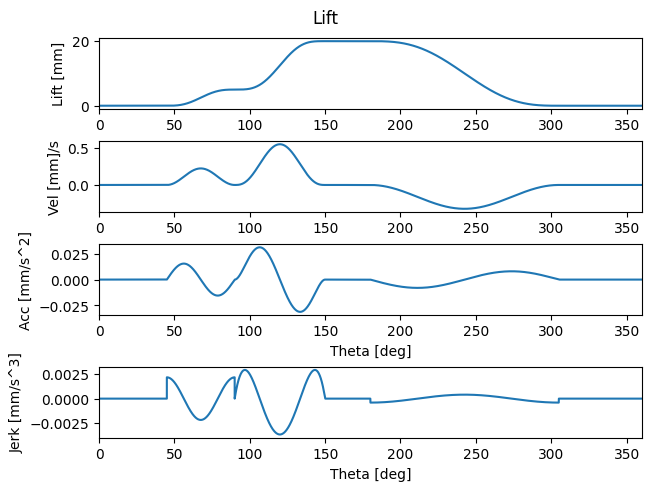

In [8]:
"""
# compute motion functions:

# a motion segment runs in one periodic cycle
# from "startangle" till "endangle",
# and moves from "startlift" till "endlift",
# with a given "motionlaw", and
# with interpolation resolution "dtheta":

def addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta,T):
    assert startangle - endangle < 0, 'End angle should be bigger than start angle'
    start_index = int(startangle/dtheta)
    end_index = int(endangle/dtheta)
    beta = endangle - startangle
    L0 = startlift
    L1 = endlift
    x = np.linspace(0, 1, (end_index - start_index))
    omega = 2*np.pi / T
    if motionlaw == 1:  # dwell
        assert L1 - L0 == 0, 'The given input does not represent a dwell'
        lift[start_index:end_index] = L0 * np.ones_like(x)
        vel_deg[start_index:end_index] = np.zeros_like(x)
        acc_deg[start_index:end_index] = np.zeros_like(x)
        jerk_deg[start_index:end_index] = np.zeros_like(x)

    elif motionlaw == 2:  # minimal acceleration / Bang-bang versnelling
        L = L1 - L0
        n = end_index - start_index
        mid = n // 2

        # lift
        lift[start_index:start_index+mid] = L * 2 * x[:mid]**2 + L0
        lift[start_index+mid:end_index] = L * (-2*x[mid:]**2 + 4*x[mid:] - 1) + L0

        # velocity
        vel_deg[start_index:start_index+mid] =  L / beta * 4 * x[:mid]
        vel_deg[start_index+mid:end_index] =  L / beta * (-4*x[mid:] + 4)

        # acceleration
        acc_deg[start_index:start_index+mid] =  L / beta**2 * 4
        acc_deg[start_index+mid:end_index] = L / beta**2 * (-4)

        jerk_deg[start_index:start_index+mid] = np.zeros_like(x[:mid])
        jerk_deg[start_index+mid:end_index] = np.zeros_like(x[mid:])

    elif motionlaw == 3:  # 3rd order polynomial (minimal rms acceleration)
        L = L1 - L0
        lift[start_index:end_index] =  L * (3 * x**2 - 2 * x**3) + L0
        vel_deg[start_index:end_index] = L / beta * (6 * x - 6 * x**2)
        acc_deg[start_index:end_index] =  L / beta**2 * (6 - 12 * x)
        jerk_deg[start_index:end_index] = L / beta**3 * (-12)

    elif motionlaw == 4:  # harmonische
        L = L1 - L0
        lift[start_index:end_index] = L * (1 - np.cos(np.pi * x)) / 2 + L0
        vel_deg[start_index:end_index] =  L / beta * np.sin(np.pi * x) * np.pi / 2
        acc_deg[start_index:end_index] =  L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2
        jerk_deg[start_index:end_index] = np.zeros_like(x)

    elif motionlaw == 5:  # minimale ruk
        L = L1 - L0
        lift[start_index: 0.25*len(x)] = L * 16*x**3 / 3 + L0
        lift[0.25*len(x): 0.75*len(x)] = L * -16*x**3 / 3 + 8*x**2 - 2*x + 1/6 + L0
        lift[0.75*len(x): end_index] = L * 16*x**3 / 3 - 16*x**2 + 16*x/3 - 13/3 + L0
        vel_deg[start_index: 0.25*len(x)] =  L / beta * 16*x**2
        vel_deg[0.25*len(x): 0.75*len(x)] =  L / beta * (-16*x**2  + 16*x - 2)
        vel_deg[0.75*len(x): end_index] =  L / beta * (16*x**2 - 32*x + 16)
        acc_deg[start_index: 0.25*len(x)] =  L / beta**2 * 32*x
        acc_deg[0.25*len(x): 0.75*len(x)] =  L / beta**2 * (-32*x + 16)
        acc_deg[0.75*len(x): end_index] =  L / beta**2 * (32*x - 32)
        jerk_deg[start_index: 0.25*len(x)] =  L / beta**3 * 32
        jerk_deg[0.25*len(x): 0.75*len(x)] =  L / beta**3 * (-32)
        jerk_deg[0.75*len(x): end_index] =  L / beta**3 * 32


    elif motionlaw == 6:  # volle cycloide
        L = L1 - L0
        lift[start_index:end_index] = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
        vel_deg[start_index:end_index] =  L / beta * (1 - np.cos(2 * np.pi * x))
        acc_deg[start_index:end_index] =  2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)
        jerk_deg[start_index:end_index] =  4 * np.pi**2 * L / beta**3 * np.cos(2 * np.pi * x)

    elif motionlaw == 7:  # 5th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
        vel_deg[start_index:end_index] = L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
        acc_deg[start_index:end_index] = L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)
        jerk_deg[start_index:end_index] =  L / beta**3 * (360 * x**2 - 360 * x + 60)

    elif motionlaw == 8:  # minimale afgeleide van de ruk
        L = L1 - L0
        i = (1 - np.sqrt(0.5))
        lift[start_index:i*len(x)] = L * 16*x**4 + L0
        lift[i*len(x): 0.5*len(x)] = L * (-16*x**4 + 128*i*x**3 - 192*i**2*x**2 + 128*i**3*x - 32*i**4) + L0
        lift[0.5*len(x): (1-i)*len(x)] = L * (1 + 16*(1 - x)**4 - 128*i*(1 - x)**3 
                                              + 192*i**2*(1 - x)**2 - 128*(1-x)*i**3 + 32*i**4) + L0
        lift[(1-i)*len(x): end_index] = L * (1 - 16*(1-x)**4) + L0
        vel_deg[start_index:i*len(x)] = L / beta * 64*x**3
        vel_deg[i*len(x): 0.5*len(x)] =  L / beta * (-64*x**3 + 384*i*x**2 - 384*i**2*x + 128*i**3)
        vel_deg[0.5*len(x): (1-i)*len(x)] =  L / beta * (-64*(1-x)**3 + 384*i*(1-x)**2 - 384*i**2*(1-x) + 128*i**3)
        vel_deg[(1-i)*len(x): end_index] = L / beta * 64*(1-x)**3
        acc_deg[start_index:i*len(x)] =  L / beta**2 * 192*x**2
        acc_deg[i*len(x): 0.5*len(x)] = L / beta**2 * (-192*x**2 + 768*i*x - 384*i**2)
        acc_deg[0.5*len(x): (1-i)*len(x)] =  L / beta**2 * (192*(1-x)**2 - 768*i*(1-x) + 384*i**2)
        acc_deg[(1-i)*len(x): end_index] =  L / beta**2 * (-192*(1-x)**2)

    elif motionlaw == 9:  # 7th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
        vel_deg[start_index:end_index] =L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
        acc_deg[start_index:end_index] = L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)
        jerk_deg[start_index:end_index] = L / beta**3 * (-4200 * x**4 + 8400 * x**3 - 5040 * x**2 + 840 * x)

    vel = vel_deg*180/np.pi
    acc = acc_deg*(180/np.pi)**2
    jerk = jerk_deg*(180/np.pi)**3

    return lift, vel_deg, acc_deg, vel, acc, jerk


"""
def plotMotionLaw(t,lift,vel,acc,jerk):
    fig1, ax1 = plt.subplots(nrows=4,ncols=1,constrained_layout=True)
    fig1.suptitle("Lift")
    
    ax1[0].plot(t, lift)
    ax1[0].set_ylabel("Lift [mm]")
    ax1[0].set_xlim([0,360])
    
    ax1[1].plot(t, vel)
    ax1[1].set_ylabel("Vel [mm]/s")
    ax1[1].set_xlim([0,360])
    
    ax1[2].plot(t, acc)
    ax1[2].set_ylabel("Acc [mm/s^2]")
    ax1[2].set_xlabel('Theta [deg]')
    ax1[2].set_xlim([0,360])

    ax1[3].plot(t, jerk)
    ax1[3].set_ylabel("Jerk [mm/s^3]")
    ax1[3].set_xlabel('Theta [deg]')
    ax1[3].set_xlim([0,360])
"""

# Add all four segments to the motion law:
lift, vel_deg, acc_deg, vel, acc, jerk = addMotionSegment(startangle1,endangle1,startlift1,endlift1,motionlaw1,dtheta,T)
lift, vel_deg, acc_deg, vel, acc, jerk = addMotionSegment(startangle2,endangle2,startlift2,endlift2,motionlaw2,dtheta,T)
lift, vel_deg, acc_deg, vel, acc, jerk = addMotionSegment(startangle3,endangle3,startlift3,endlift3,motionlaw3,dtheta,T)
lift, vel_deg, acc_deg, vel, acc, jerk = addMotionSegment(startangle4,endangle4,startlift4,endlift4,motionlaw4,dtheta,T)
lift, vel_deg, acc_deg, vel, acc, jerk = addMotionSegment(startangle5,endangle5,startlift5,endlift5,motionlaw5,dtheta,T)
lift, vel_deg, acc_deg, vel, acc, jerk = addMotionSegment(startangle6,endangle6,startlift6,endlift6,motionlaw6,dtheta,T)
"""
# Plot the motion law
plotMotionLaw(theta_deg,lift,vel_deg,acc_deg, jerk_deg)

plt.show()


<h4> Analysis of the motion profiles </h4>
Based on the acceleration profile, a small discontinuity can be seen between the precompression and the full compression. This is not a major problem because it is only a very small discontinuity. If you want to eliminate this, it is necessary to use a 7th-order polynomial for the precompression as well. For the first design, we choose not to do this, as it would drive up the cost. Otherwise, the jerk is never infinite, which leads to a fairly precise movement of the follower.

In [9]:
import os
os.path.exists("images/motion-law-summary.png")

True

<h>Samenvattende tabel</h>
<div style=" display: grid; place-items: center; place-content: center;">
 <img style="border: 0; display: inline-block;" height="100%"
      src="images/motion-law-summary.png"
 >
</div>

In [10]:
# utility functions for external load

def addLoadSegment(startangleload,endangleload,startload,endload,dtheta):
    assert startangleload - endangleload < 0, 'End angle should be bigger than start angle'
    start_index = int(startangleload/dtheta)
    end_index = int(endangleload/dtheta)
    theta_segment = theta_deg[start_index:end_index]
    ext_load[start_index:end_index] = (endload - startload)/(endangleload - startangleload)*(theta_segment - startangleload) + startload

    return ext_load

def plotExternalLoad(theta_deg,ext_load):
    plt.figure()
    plt.plot(theta_deg, ext_load)
    plt.xlabel('Theta [deg]')
    plt.ylabel('External load [N]')
    plt.xlim([0,360])
    plt.title('External load')


# Design cam-follower geometry
First without including excentricity e

In [11]:
# utility functions for cam profile design (with eccentricity = 0!)


# relate sampled R0 values to pressure angle \alpha:
def Kloomok_Muffley_R0(startangle, endangle, beta, startlift, endlift, motionlaw):
    R0_vec = np.arange(0, 100, 0.1)
    alpha_max = np.zeros_like(R0_vec)
    
    L0 = startlift
    L1 = endlift
    start_index = int(startangle/dtheta)
    end_index = int(endangle/dtheta)
    beta = beta * np.pi / 180
		# 100 samples in dimensionless "arc length" of motion law:
    #x = np.linspace(0, 1, (end_index - start_index))
    x = np.arange(0, 1, 0.01)
    alpha_limit = 35 #degrees

    for i in range(len(R0_vec)):
        R0 = R0_vec[i]

        if motionlaw == 1:  # dwell
            assert L1 - L0 == 0, 'The given input does not represent a dwell'
            lift = L0 * np.ones_like(x)
            vel_deg = np.zeros_like(x)
            acc_deg = np.zeros_like(x)
            jerk_deg = np.zeros_like(x)

        elif motionlaw == 2:  # minimal acceleration / Bang-bang versnelling
            L = L1 - L0
            n = end_index - start_index
            mid = n // 2

            # lift
            lift[start_index:start_index+mid] = L * 2 * x[:mid]**2 + L0
            lift[start_index+mid:end_index] = L * (-2*x[mid:]**2 + 4*x[mid:] - 1) + L0

            # velocity
            vel_deg[start_index:start_index+mid] =  L / beta * 4 * x[:mid]
            vel_deg[start_index+mid:end_index] = L / beta * (-4*x[mid:] + 4)

            # acceleration
            acc_deg[start_index:start_index+mid] = L / beta**2 * 4
            acc_deg[start_index+mid:end_index] = L / beta**2 * (-4)

            jerk_deg[start_index:start_index+mid] = np.zeros_like(x[:mid])
            jerk_deg[start_index+mid:end_index] = np.zeros_like(x[mid:])

        elif motionlaw == 3:  # 3rd order polynomial (minimal rms acceleration)
            L = L1 - L0
            lift =  L * (3 * x**2 - 2 * x**3) + L0
            vel_deg= L / beta * (6 * x - 6 * x**2)
            acc_deg =  L / beta**2 * (6 - 12 * x)
            jerk_deg = L / beta**3 * (-12)

        elif motionlaw == 4:  # harmonische
            L = L1 - L0
            lift = L * (1 - np.cos(np.pi * x)) / 2 + L0
            vel_deg = L / beta * np.sin(np.pi * x) * np.pi / 2
            acc_deg =  L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2
            jerk_deg = np.zeros_like(x)

        elif motionlaw == 5:  # minimale ruk
            L = L1 - L0
            lift[start_index: 0.25*len(x)] = L * 16*x**3 / 3 + L0
            lift[0.25*len(x): 0.75*len(x)] = L * -16*x**3 / 3 + 8*x**2 - 2*x + 1/6 + L0
            lift[0.75*len(x): end_index] = L * 16*x**3 / 3 - 16*x**2 + 16*x/3 - 13/3 + L0
            vel_deg[start_index: 0.25*len(x)] = L / beta * 16*x**2
            vel_deg[0.25*len(x): 0.75*len(x)] = L / beta * (-16*x**2  + 16*x - 2)
            vel_deg[0.75*len(x): end_index] =  L / beta * (16*x**2 - 32*x + 16)
            acc_deg[start_index: 0.25*len(x)] = L / beta**2 * 32*x
            acc_deg[0.25*len(x): 0.75*len(x)] =  L / beta**2 * (-32*x + 16)
            acc_deg[0.75*len(x): end_index] =  L / beta**2 * (32*x - 32)
            jerk_deg[start_index: 0.25*len(x)] = L / beta**3 * 32
            jerk_deg[0.25*len(x): 0.75*len(x)] = L / beta**3 * (-32)
            jerk_deg[0.75*len(x): end_index] = L / beta**3 * 32


        elif motionlaw == 6:  # volle cycloide
            L = L1 - L0
            lift = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
            vel_deg = L / beta * (1 - np.cos(2 * np.pi * x))
            acc_deg =  2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)
            jerk_deg =  4 * np.pi**2 * L / beta**3 * np.cos(2 * np.pi * x)

        elif motionlaw == 7:  # 5th degree poly
            L = L1 - L0
            lift = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
            vel_deg =  L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
            acc_deg =  L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)
            jerk_deg =  L / beta**3 * (360 * x**2 - 360 * x + 60)

        elif motionlaw == 8:  # minimale afgeleide van de ruk
            L = L1 - L0
            i = (1 - np.sqrt(0.5))
            lift[start_index:i*len(x)] = L * 16*x**4 + L0
            lift[i*len(x): 0.5*len(x)] = L * (-16*x**4 + 128*i*x**3 - 192*i**2*x**2 + 128*i**3*x - 32*i**4) + L0
            lift[0.5*len(x): (1-i)*len(x)] = L * (1 + 16*(1 - x)**4 - 128*i*(1 - x)**3 
                                                + 192*i**2*(1 - x)**2 - 128*(1-x)*i**3 + 32*i**4) + L0
            lift[(1-i)*len(x): end_index] = L * (1 - 16*(1-x)**4) + L0
            vel_deg[start_index:i*len(x)] =  L / beta * 64*x**3
            vel_deg[i*len(x): 0.5*len(x)] = L / beta * (-64*x**3 + 384*i*x**2 - 384*i**2*x + 128*i**3)
            vel_deg[0.5*len(x): (1-i)*len(x)] = L / beta * (-64*(1-x)**3 + 384*i*(1-x)**2 - 384*i**2*(1-x) + 128*i**3)
            vel_deg[(1-i)*len(x): end_index] =  L / beta * 64*(1-x)**3
            acc_deg[start_index:i*len(x)] =  L / beta**2 * 192*x**2
            acc_deg[i*len(x): 0.5*len(x)] =  L / beta**2 * (-192*x**2 + 768*i*x - 384*i**2)
            acc_deg[0.5*len(x): (1-i)*len(x)] =  L / beta**2 * (192*(1-x)**2 - 768*i*(1-x) + 384*i**2)
            acc_deg[(1-i)*len(x): end_index] =  L / beta**2 * (-192*(1-x)**2)

        elif motionlaw == 9:  # 7th degree poly
            L = L1 - L0
            lift = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
            vel_deg =  L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
            acc_deg =  L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)
            jerk_deg =  L / beta**3 * (-4200 * x**4 + 8400 * x**3 - 5040 * x**2 + 840 * x)

        alpha = np.arctan2(vel_deg, R0 + lift)
        alpha_max[i] = np.max(np.abs(alpha)) * 180 / np.pi

    # Find the R0 value where alpha_max is closest to 35 degrees
    idx_closest = np.argmin(np.abs(alpha_max - alpha_limit))
    R0_best = R0_vec[idx_closest]
    alpha_best = alpha_max[idx_closest]
    
    plt.figure()
    plt.plot(R0_vec, alpha_max, label=r'$\alpha_{max}$')
    plt.axhline(y=alpha_limit, color='r', linestyle='--', label=f'{alpha_limit} degrees')
    plt.axvline(x=R0_best, color='g', linestyle='--', label=f'Optimal $R_0$ = {R0_best:.1f} mm')
    plt.scatter(R0_best, alpha_best, color='g', zorder=3)
    plt.grid()
    plt.xlabel('$R_0$ (mm)')
    plt.ylabel(r'$\alpha_{max}$ (degree)')
    plt.legend()
    plt.xlim([0, 100])
    plt.show()


# relate given R0 value to samples of curvature radii of motion law:
def Kloomok_Muffley_follower_radius(R0, startlift, endlift, beta_target, motionlaw):
    beta_vec = np.arange(0, 360, 0.1)
    rho_min = np.zeros_like(beta_vec)
    start_index = int(startangle/dtheta)
    end_index = int(endangle/dtheta)
    L0 = startlift
    L1 = endlift

    for i in range(len(beta_vec)):
        beta = beta_vec[i] * np.pi / 180
        theta = np.linspace(0, beta_vec[i], 100) * np.pi / 180
        x = theta / beta

        if motionlaw == 1:  # dwell
            assert L1 - L0 == 0, 'The given input does not represent a dwell'
            lift = L0 * np.ones_like(x)
            vel_deg = np.zeros_like(x)
            acc_deg = np.zeros_like(x)
            jerk_deg = np.zeros_like(x)

        elif motionlaw == 2:  # minimal acceleration / Bang-bang versnelling
            L = L1 - L0
            n = end_index - start_index
            mid = n // 2

            # lift
            lift[start_index:start_index+mid] = L * 2 * x[:mid]**2 + L0
            lift[start_index+mid:end_index] = L * (-2*x[mid:]**2 + 4*x[mid:] - 1) + L0

            # velocity
            vel_deg[start_index:start_index+mid] =  L / beta * 4 * x[:mid]
            vel_deg[start_index+mid:end_index] = L / beta * (-4*x[mid:] + 4)

            # acceleration
            acc_deg[start_index:start_index+mid] = L / beta**2 * 4
            acc_deg[start_index+mid:end_index] = L / beta**2 * (-4)

            jerk_deg[start_index:start_index+mid] = np.zeros_like(x[:mid])
            jerk_deg[start_index+mid:end_index] = np.zeros_like(x[mid:])

        elif motionlaw == 3:  # 3rd order polynomial (minimal rms acceleration)
            L = L1 - L0
            lift =  L * (3 * x**2 - 2 * x**3) + L0
            vel_deg= L / beta * (6 * x - 6 * x**2)
            acc_deg =  L / beta**2 * (6 - 12 * x)
            jerk_deg = L / beta**3 * (-12)

        elif motionlaw == 4:  # harmonische
            L = L1 - L0
            lift = L * (1 - np.cos(np.pi * x)) / 2 + L0
            vel_deg = L / beta * np.sin(np.pi * x) * np.pi / 2
            acc_deg =  L / beta**2 * np.cos(np.pi * x) * np.pi**2 / 2
            jerk_deg = np.zeros_like(x)

        elif motionlaw == 5:  # minimale ruk
            L = L1 - L0
            lift[start_index: 0.25*len(x)] = L * 16*x**3 / 3 + L0
            lift[0.25*len(x): 0.75*len(x)] = L * -16*x**3 / 3 + 8*x**2 - 2*x + 1/6 + L0
            lift[0.75*len(x): end_index] = L * 16*x**3 / 3 - 16*x**2 + 16*x/3 - 13/3 + L0
            vel_deg[start_index: 0.25*len(x)] = L / beta * 16*x**2
            vel_deg[0.25*len(x): 0.75*len(x)] = L / beta * (-16*x**2  + 16*x - 2)
            vel_deg[0.75*len(x): end_index] =  L / beta * (16*x**2 - 32*x + 16)
            acc_deg[start_index: 0.25*len(x)] = L / beta**2 * 32*x
            acc_deg[0.25*len(x): 0.75*len(x)] =  L / beta**2 * (-32*x + 16)
            acc_deg[0.75*len(x): end_index] =  L / beta**2 * (32*x - 32)
            jerk_deg[start_index: 0.25*len(x)] = L / beta**3 * 32
            jerk_deg[0.25*len(x): 0.75*len(x)] = L / beta**3 * (-32)
            jerk_deg[0.75*len(x): end_index] = L / beta**3 * 32


        elif motionlaw == 6:  # volle cycloide
            L = L1 - L0
            lift = L * (x - np.sin(2 * np.pi * x) / (2 * np.pi)) + L0
            vel_deg = L / beta * (1 - np.cos(2 * np.pi * x))
            acc_deg =  2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)
            jerk_deg =  4 * np.pi**2 * L / beta**3 * np.cos(2 * np.pi * x)

        elif motionlaw == 7:  # 5th degree poly
            L = L1 - L0
            lift = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
            vel_deg =  L / beta * (30 * x**4 - 60 * x**3 + 30 * x**2)
            acc_deg =  L / beta**2 * (120 * x**3 - 180 * x**2 + 60 * x)
            jerk_deg =  L / beta**3 * (360 * x**2 - 360 * x + 60)

        elif motionlaw == 8:  # minimale afgeleide van de ruk
            L = L1 - L0
            i = (1 - np.sqrt(0.5))
            lift[start_index:i*len(x)] = L * 16*x**4 + L0
            lift[i*len(x): 0.5*len(x)] = L * (-16*x**4 + 128*i*x**3 - 192*i**2*x**2 + 128*i**3*x - 32*i**4) + L0
            lift[0.5*len(x): (1-i)*len(x)] = L * (1 + 16*(1 - x)**4 - 128*i*(1 - x)**3 
                                                + 192*i**2*(1 - x)**2 - 128*(1-x)*i**3 + 32*i**4) + L0
            lift[(1-i)*len(x): end_index] = L * (1 - 16*(1-x)**4) + L0
            vel_deg[start_index:i*len(x)] =  L / beta * 64*x**3
            vel_deg[i*len(x): 0.5*len(x)] = L / beta * (-64*x**3 + 384*i*x**2 - 384*i**2*x + 128*i**3)
            vel_deg[0.5*len(x): (1-i)*len(x)] = L / beta * (-64*(1-x)**3 + 384*i*(1-x)**2 - 384*i**2*(1-x) + 128*i**3)
            vel_deg[(1-i)*len(x): end_index] =  L / beta * 64*(1-x)**3
            acc_deg[start_index:i*len(x)] =  L / beta**2 * 192*x**2
            acc_deg[i*len(x): 0.5*len(x)] =  L / beta**2 * (-192*x**2 + 768*i*x - 384*i**2)
            acc_deg[0.5*len(x): (1-i)*len(x)] =  L / beta**2 * (192*(1-x)**2 - 768*i*(1-x) + 384*i**2)
            acc_deg[(1-i)*len(x): end_index] =  L / beta**2 * (-192*(1-x)**2)

        elif motionlaw == 9:  # 7th degree poly
            L = L1 - L0
            lift = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
            vel_deg =  L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
            acc_deg =  L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)
            jerk_deg =  L / beta**3 * (-4200 * x**4 + 8400 * x**3 - 5040 * x**2 + 840 * x)

        rho = ((R0 + lift)**2 + vel_deg**2)**(3/2) / ((R0 + lift)**2 + 2 * vel_deg**2 - (R0 + lift) * acc_deg)
        rho_min[i] = np.min(np.abs(rho))

    # Find the rho_min value at the given beta_target
    idx_target = np.argmin(np.abs(beta_vec - beta_target))
    rho_target = rho_min[idx_target]

    plt.figure()
    plt.plot(beta_vec, rho_min, label=r'$\rho_{min}$')
    plt.axvline(x=beta_target, color='r', linestyle='--', label=rf'$\beta = {beta_target:.1f}^\circ$')
    plt.scatter(beta_target, rho_target, color='r', zorder=3, label=rf'$\rho_{{min}}$ at $\beta = {beta_target:.1f}^\circ$: {rho_target:.2f} mm')

    plt.grid()
    plt.xlabel(r'$\beta$ (degrees)')
    plt.ylabel(r'$\rho_{min}$ (mm)')
    plt.xlim([0, 360])
    plt.legend()
    plt.show()


Plotting the pitch radius in function of the pressure angle. As a design choice, the pressure angle should be below 35° to minimize the friction between the cam and the follower. Based on this criterium, a satistfactory pitch radius is chosen 

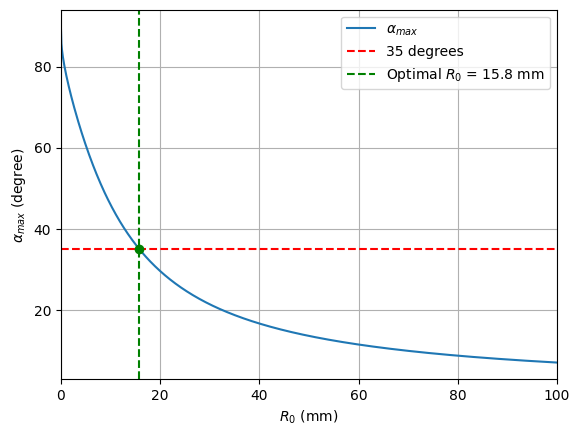

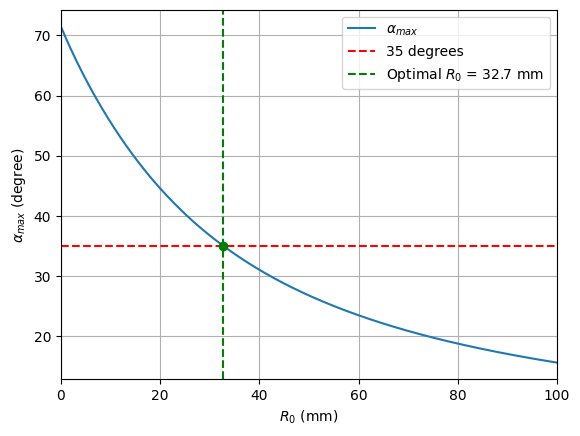

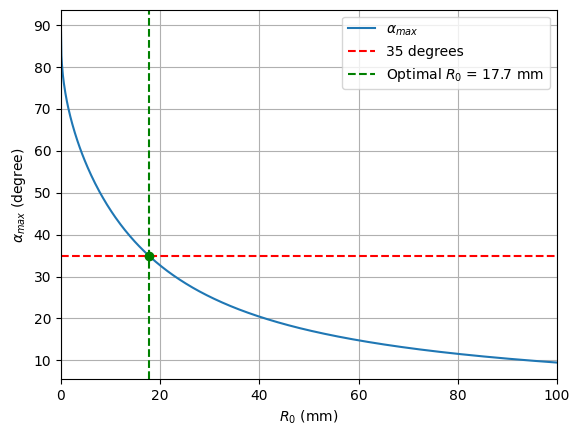

In [12]:
# other sections are all dwell motion laws which don't inlfuence the choice of R0

startangle = startangle2 
endangle = endangle2   
beta = theta_seg2  # rotation length for first motion segment
startlift = startlift2  
endlift = endlift2  
motionlaw = motionlaw2  

Kloomok_Muffley_R0(startangle, endangle, beta, startlift, endlift, motionlaw) # section 2

startangle = startangle3 
endangle = endangle3   
beta = theta_seg3  # rotation length for first motion segment
startlift = startlift3
endlift = endlift3 
motionlaw = motionlaw3  

Kloomok_Muffley_R0(startangle, endangle, beta, startlift, endlift, motionlaw) # section 2

startangle = startangle5 
endangle = endangle5 
beta = theta_seg5  # rotation length for first motion segment
startlift = startlift5
endlift = endlift5 
motionlaw = motionlaw5  

Kloomok_Muffley_R0(startangle, endangle, beta, startlift, endlift, motionlaw) #section 5


Omwille van de 7e orde polynoom moeten we hier kiezen voor een maximale basis straal van 32.7mm. Praktisch wordt R0 = 35mm gekozen, zodat we toch een marge behouden op de drukhoek. Ook voor ondersnijding zal deze marge ten goede komen. De extra marge op de basisstraal zal ook voor een grotere inertie zorgen. In bestaande machines is de main compression roll het grootste element. De typscihe diameter range is: 60 - 120 mm. Als we onze steek straal kiezen binnen deze range zijn we nog beter af voor de drukhoek en blijven we ook in dezelfde grootte orders werken als de bestaande designs.

Omdat de rolvolger een straal van $R_r = 35$ mm heeft, kiezen we een grotere praktische pitch radius $R_0 = 80$ mm. De effectieve basisstraal van de nok wordt daardoor:


$R_b = R_0 - R_r = 80 - 35 = 45 \text{ mm}$


In de verdere berekeningen wordt \(R_0\) dus gebruikt als pitch radius, niet als basisstraal.

In [13]:
# Geometric radii
# R0 is used as the pitch radius: distance from cam center to roller center at zero lift.
# The actual cam base radius is smaller by one roller radius.

R0 = 80      # mm, pitch radius / steekstraal
Rr = 35      # mm, roller follower radius / rolvolgerstraal

base_radius = R0 - Rr   # mm, actual cam base radius

print(f"Pitch radius R0: {R0:.1f} mm")
print(f"Roller radius Rr: {Rr:.1f} mm")
print(f"Cam base radius: {base_radius:.1f} mm")

Pitch radius R0: 80.0 mm
Roller radius Rr: 35.0 mm
Cam base radius: 45.0 mm


Plotting the base radius in function of the minimal undercut to determine a satisfactory follower radius. The equations on which the choice is based are: $$\rho_{\text{min}} \gt R_r.$$ and 
$$ \rho =
 \frac{\left [ R^2 + (f'(\theta))^2 \right ]^{\frac{3}{2}}}
      {R^2 + 2(f'(\theta))^2 - R\, f''(\theta)},
\quad \text{met } R= R_0 +f(\theta).
$$

C:\Users\Vikto\AppData\Local\Temp\ipykernel_26000\1635019563.py:150: RuntimeWarning: invalid value encountered in divide
  x = theta / beta
C:\Users\Vikto\AppData\Local\Temp\ipykernel_26000\1635019563.py:212: RuntimeWarning: divide by zero encountered in scalar divide
  vel_deg = L / beta * (1 - np.cos(2 * np.pi * x))
C:\Users\Vikto\AppData\Local\Temp\ipykernel_26000\1635019563.py:213: RuntimeWarning: divide by zero encountered in scalar divide
  acc_deg =  2 * np.pi * L / beta**2 * np.sin(2 * np.pi * x)
C:\Users\Vikto\AppData\Local\Temp\ipykernel_26000\1635019563.py:214: RuntimeWarning: divide by zero encountered in scalar divide
  jerk_deg =  4 * np.pi**2 * L / beta**3 * np.cos(2 * np.pi * x)


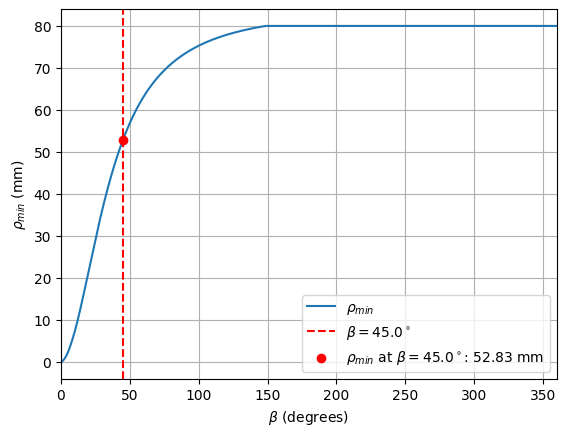

C:\Users\Vikto\AppData\Local\Temp\ipykernel_26000\1635019563.py:243: RuntimeWarning: divide by zero encountered in scalar divide
  vel_deg =  L / beta * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
C:\Users\Vikto\AppData\Local\Temp\ipykernel_26000\1635019563.py:244: RuntimeWarning: divide by zero encountered in scalar divide
  acc_deg =  L / beta**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)
C:\Users\Vikto\AppData\Local\Temp\ipykernel_26000\1635019563.py:245: RuntimeWarning: divide by zero encountered in scalar divide
  jerk_deg =  L / beta**3 * (-4200 * x**4 + 8400 * x**3 - 5040 * x**2 + 840 * x)


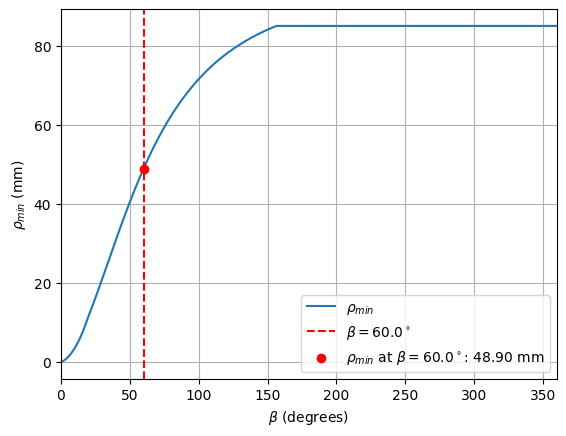

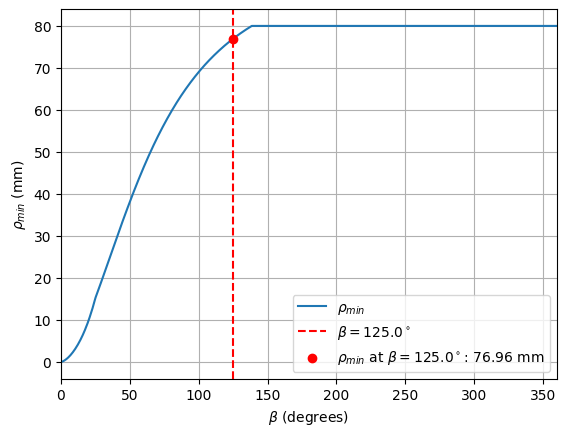

In [14]:
Kloomok_Muffley_follower_radius(R0,startlift2,endlift2,theta_seg2, motionlaw2) # section 2
Kloomok_Muffley_follower_radius(R0,startlift3,endlift3,theta_seg3, motionlaw3) # section 3
Kloomok_Muffley_follower_radius(R0,startlift5,endlift5,theta_seg5, motionlaw5) # section 5


- Segment 2: $\rho_{min}$ = 52.83 mm  
- Segment 3: $\rho_{min}$ = 48.9 mm  
- Segment 4: $\rho_{min}$ = 76.96 mm

**Undercutting is avoided by ensuring: $ \rho_{min} > R_r$** ($ \rho_{min}$ = minimum curvature radius of the pitch curve, $R_r$ = radius of the follower)

**We choose $R_r$ = 35 mm**

In [15]:
# Rr = 35 

Pressure angle and cam contour

In [16]:
# utility functions for pressure angle

def calculatePressureAngle(vel,exc,base_radius,follower_radius,lift):
    pressure_angle = np.arctan((vel-exc)/(np.sqrt((base_radius+follower_radius)**2-exc**2)+lift))
    return pressure_angle

def plotPressureAngle(theta_deg,pressure_angle):
    plt.figure()
    plt.plot(theta_deg, pressure_angle*180/np.pi)
    plt.xlabel('rotation [deg]')
    plt.ylabel('Pressure angle [deg]')
    plt.xlim([0,360])

In [17]:
# utility functions for curvature radius

def calculateRadiusCurvature(base_radius,follower_radius,exc,theta,lift,vel,acc):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2) #Nortron, Kinematic and dynamics of Machinery eq. 8.31c
    lambda_ = -theta - np.arctan2(exc, d+lift) + np.pi/2 # Nortron, Kinematic and dynamics of Machinery eq. 8.34, adapted for vertical follower instead of a horizontal one (--> + pi/2)
    dlambda = -1 + exc/((d+lift)**2 + exc**2) * vel # derivative of lambda with repect to theta
    ddlambda = exc/((d+lift)**2 + exc**2)*acc - 2*exc*(d+lift)*vel**2/((d+lift)**2 + exc**2)**2 # 2nd derivative of lambda with repect to theta

    g = np.sqrt((d+lift)**2 + exc**2) 
    dg = vel*(d+lift)/np.sqrt((d+lift)**2 + exc**2) # derivative of g with repect to theta
    ddg = (vel**2  + acc*(d + lift))/np.sqrt((d + lift)**2 + exc**2) - (vel**2*(d + lift)**2)/((d + lift)**2 + exc**2)**(3/2) # 2nd derivative of g with repect to theta

    h = np.sin(lambda_)
    dh = np.cos(lambda_)*dlambda # derivative of h with repect to theta
    ddh = -np.sin(lambda_)*dlambda**2 + np.cos(lambda_)*ddlambda # 2nd derivative of h with repect to theta
    f = np.cos(lambda_)
    df = -np.sin(lambda_)*dlambda #derivative of f with repect to theta
    ddf = -np.cos(lambda_)*dlambda**2 - np.sin(lambda_)*ddlambda # 2nd derivative of f with repect to theta

    dx = df*g + f*dg #derivative of x with repect to theta
    ddx = ddf*g + 2*df*dg + f*ddg # 2nd derivative of x with repect to theta
    dy = dh*g + h*dg # derivative of y with repect to theta
    ddy = ddh*g + 2*dh*dg + h*ddg # 2nd derivative of y with repect to theta

    roc_pitch = -(dx**2 + dy**2)**(3/2) / (dx*ddy - dy*ddx) # general forumula for the radius of curvature
    roc_cam = roc_pitch - follower_radius

    return roc_pitch, roc_cam

def plotRadiusCurvature(theta_deg,roc_pitch,roc_cam):
    inds = np.where(np.abs(np.diff(roc_pitch)/dtheta)<1e3)[0]
    maxi = max(10, max(roc_pitch[inds+1]))
    mini = min(-10, min(roc_pitch[inds+1]))
    plt.figure()
    plt.plot(theta_deg, roc_pitch)
    plt.plot(theta_deg, roc_cam)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Radius of curvature [mm]')
    plt.xlim([0,360])
    plt.ylim([mini,maxi])
    plt.grid()
    plt.title('Radius of curvature')

def plotCamContour(base_radius, follower_radius, exc, theta, lift, pressure_angle, dtheta):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2)
    lambda_ = -theta - np.arctan2(exc, d + lift) + np.pi / 2
    xpitch =  - np.cos(lambda_) * np.sqrt((d + lift)**2 + exc**2)
    ypitch = -np.sin(lambda_) * np.sqrt((d + lift)**2 + exc**2)  # negated

    xcam = xpitch - follower_radius * np.cos(-theta + pressure_angle + 3 * np.pi / 2)
    ycam = ypitch - follower_radius * np.sin(-theta + pressure_angle + 3 * np.pi / 2)  # negated

    pitch_curve = np.array([xpitch, ypitch])
    cam_curve   = np.array([xcam,   ycam])

    x_rolfol_center = -exc
    y_rolfol_center = -(d + lift[0])                              # negated: follower below cam
    x_rolfol = follower_radius * np.cos(theta) + x_rolfol_center
    y_rolfol = follower_radius * np.sin(theta) + y_rolfol_center

    min_distance_center_roller_to_bore = 2 * follower_radius
    height_bore = follower_radius
    width_block_on_follower  = base_radius / 2
    height_block_on_follower = base_radius / 2

    x_boreleft  = np.array([-exc - 5, -exc - 1, -exc - 1, -exc - 5])
    x_boreright = np.array([-exc + 5, -exc + 1, -exc + 1, -exc + 5])

    # bore is now below
    y_bore_top    = -(d + max(lift) + min_distance_center_roller_to_bore)
    y_bore_bottom = -(d + max(lift) + min_distance_center_roller_to_bore + height_bore)
    y_bore = np.array([y_bore_top, y_bore_top, y_bore_bottom, y_bore_bottom])

    length_follower = abs(y_bore_bottom) - (d + lift[0]) - follower_radius + 0.2

    # stem goes downward
    x_follower = np.array([x_rolfol_center, x_rolfol_center])
    y_follower = np.array([y_rolfol_center - follower_radius,
                            y_rolfol_center - follower_radius - length_follower])

    # block hangs below stem
    x_block_on_follower = np.array([-width_block_on_follower,  width_block_on_follower,
                                     width_block_on_follower, -width_block_on_follower]) + x_follower[0]
    y_block_on_follower = np.array([0, 0, -height_block_on_follower, -height_block_on_follower]) + y_follower[1]

    ref_line = np.array([[0, 0], [0, -base_radius]])              # reference line points downward

    # pressure angle line flipped
    x_pressangle = np.array([x_rolfol_center -  follower_radius * np.sin(pressure_angle[0]),
                              x_rolfol_center + follower_radius * np.sin(pressure_angle[0])])
    y_pressangle = np.array([y_rolfol_center + follower_radius * np.cos(pressure_angle[0]),
                               y_rolfol_center - follower_radius * np.cos(pressure_angle[0])])

    plt.figure()
    plt.fill(cam_curve[0, ::int(1 / dtheta)], cam_curve[1, ::int(1 / dtheta)], 'b')
    plt.fill(x_rolfol[::int(1 / dtheta)],     y_rolfol[::int(1 / dtheta)],     'g')
    plt.plot(pitch_curve[0, ::int(1 / dtheta)], pitch_curve[1, ::int(1 / dtheta)], '--r')
    plt.plot(0, 0, 'r+')
    plt.plot(x_pressangle, y_pressangle, 'r--')
    plt.plot(ref_line[0, :], ref_line[1, :], 'r--')
    plt.plot(x_boreleft,  y_bore, 'r')
    plt.plot(x_boreright, y_bore, 'r')
    plt.plot(x_follower,  y_follower, 'r')
    plt.fill(x_block_on_follower, y_block_on_follower, 'g')

    xlimits = [min(pitch_curve[0, :]), max(pitch_curve[0, :])]
    ylimits = [y_follower[1] - height_block_on_follower, max(pitch_curve[1, :])]

    plt.xlim(np.array(xlimits) * 1.2)
    plt.ylim([ylimits[0] * 1.05, ylimits[1] * 1.05])
    plt.gca().set_aspect('equal')
    plt.grid(True)
    plt.title('Cam contour [mm]')


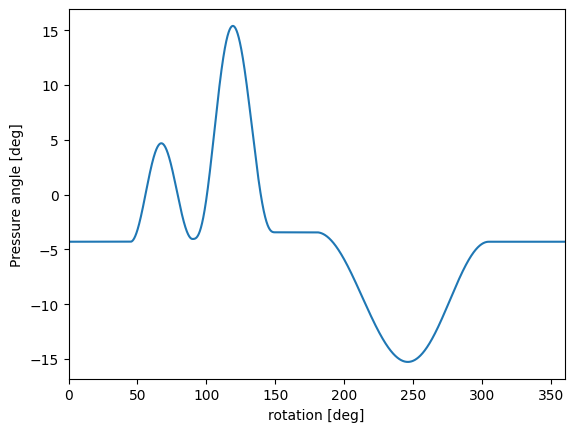

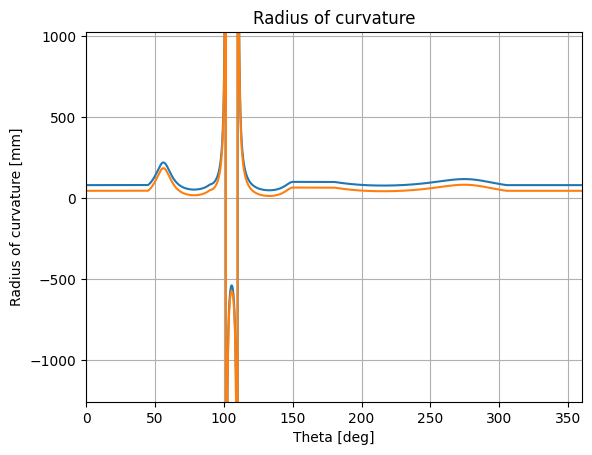

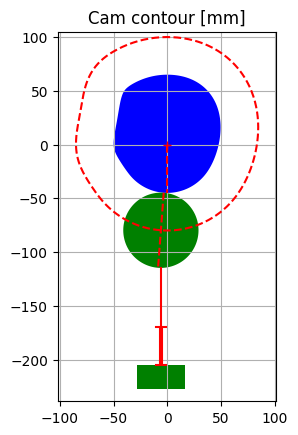

In [18]:
# base_radius = R0 - Rr
exc = 6 # adding this excentricity to balance the pressure angle over the entire profile. A better option would be to add more excentricity
        # such that the pressure angle is smaller at the beginning of the motion instead at the end where the correct motion is less important (since the follower is already moving at a high velocity and the cam is not accelerating anymore, see section 5)


# Calculate pressure angle
pressure_angle = calculatePressureAngle(vel, exc, base_radius, Rr, lift)
# Plot pressure angle
plotPressureAngle(theta_deg, pressure_angle)

# Calculate radius of curvature
roc_pitch, roc_cam = calculateRadiusCurvature(base_radius,Rr,exc,theta,lift,vel,acc)

# Plot the radius of curvature
plotRadiusCurvature(theta_deg,roc_pitch,roc_cam)

# Plot the cam contour
plotCamContour(base_radius,Rr,exc,theta,lift,pressure_angle,dtheta)



# Validation of the forces on the CAM


**Vertikaal krachtevenwicht**:

$$
N\, \cos(\alpha) = F_{\text{func}} + F_v + m \frac{d^2y}{dt^2} + m\, g\, \cos(\gamma) + \mu R,
$$

met:

- $m$: de massa van het volger-lichaam.
- $\gamma$: hoek tussen de volgerbeweging en de vertikale.
- $\mu$: Coulomb-wrijvingsco&euml;fficient.
- $g$: zwaartekrachtversnelling.
- $y$: verplaatsing van de volger, positief in opwaartse richting.
- $\alpha$: drukhoek.

**Resulterende contactkracht**

Indien:
- de volger een perfect star lichaam is.
- de glijwrijving in de volger verwaarloosbaar is.
- de rotatiesnelheid van de nok constant is.
- er permanent contact is tussen nok en volger, d.w.z. $y(t) := S(t) = S(\theta/\omega)$.

Dan is de contact-normaalkracht $N$ tussen nok en volger
$$
N= \frac{F_{\text{func}} + F_{v0} + k_v S + m \omega^2 \frac{d^2 S(\theta)}{d\theta^2} - mg \, \cos(\gamma)}{\cos(\alpha)},
$$

met $k_v$ de veerconstante, en $F_{v0}$ de voorspanning in die veer, by $S=0$.

#### Bepaling preload en veerconstante
De preload is belangrijk om te zorgen dat de volger tegen de zwaartekracht terug naar de nok kan worden gebracht. Verder moet met een combinatie van de preload en de veerconstante ervoor gezorgd worden dat de volger altijd in contact is met de nok. Dit betekent dat de minimale resulterende normaalkracht groter dan of gelijk moet zijn aan 0N.

Meer preload:

- <span style="color:red">verhoogt de normaalkracht overal</span>
- <span style="color:red">verhoogt dus ook wrijving en motorkoppel overal</span>
- minstens 150N nodig om de zwaartekracht tegen te werken in de beweging terug naar de startpositie

Grotere veerconstante:

- <span style="color:red">geeft hoge normaalkracht bij maximale indrukking</span>
- <span style="color:red">verhoogt piekkracht en piekkoppel</span>

In [19]:
def calculateForce(rpm,lift,spring_constant,spring_preload,pressure_angle,ext_load,mass,acc):
    omega = rpm*2*np.pi/60
    normalforce_spring = lift*spring_constant/np.cos(pressure_angle)
    preload_force = spring_preload / np.cos(pressure_angle)
    gravity_force = - mass*9.81 / np.cos(pressure_angle)
    normalforce_load = ext_load/np.cos(pressure_angle)
    normalforce_acc = mass*acc/1000*(omega**2)/np.cos(pressure_angle) # versnelling is in mm/s^2, dus delen door 1000 om naar m/s^2 te gaan
    normalforce_tot = normalforce_spring + normalforce_load + normalforce_acc + gravity_force + preload_force
    force_x = normalforce_tot * np.sin(pressure_angle)
    force_y = normalforce_tot * np.cos(pressure_angle)

    return normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y, gravity_force, preload_force

def plotForces(theta_deg, normalforce_tot, normalforce_acc, normalforce_load, normalforce_spring, force_x, force_y, gravity_force, preload_force):
    plt.figure()
    plt.plot(theta_deg, normalforce_tot)
    plt.plot(theta_deg, normalforce_acc, '--r')
    plt.plot(theta_deg, normalforce_load, ':g')
    plt.plot(theta_deg, normalforce_spring, '-.m')
    plt.plot(theta_deg, gravity_force, ':k')
    plt.plot(theta_deg, preload_force, ':c')
    plt.xlabel('Theta [deg]')
    plt.ylabel('Normal force [N]')
    plt.xlim([0, 360])
    plt.legend(['total', 'acc', 'extload', 'spring', 'gravity', 'preload'])
    plt.title('Normal force')

    plt.figure()
    plt.plot(theta_deg, normalforce_tot, 'b')
    plt.axhline(y=0, color='k', linewidth=0.8)
    plt.fill_between(theta_deg, normalforce_tot, 0,
                     where=(normalforce_tot < 0),
                     color='red', alpha=0.4, label='Contact lost (F < 0)')
    plt.fill_between(theta_deg, normalforce_tot, 0,
                     where=(normalforce_tot >= 0),
                     color='green', alpha=0.2, label='Contact maintained (F ≥ 0)')

    # Indicate minimum value
    min_force = np.min(normalforce_tot)
    min_theta = theta_deg[np.argmin(normalforce_tot)]
    plt.annotate(f'Min: {min_force:.2f} N',
                 xy=(min_theta, min_force),
                 xytext=(min_theta + 20, min_force - 0.1 * abs(min_force)),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 color='red', fontsize=9)
    plt.scatter(min_theta, min_force, color='red', zorder=5)

    plt.xlabel('Theta [deg]')
    plt.ylabel('Normal force [N]')
    plt.xlim([0, 360])
    plt.legend()
    plt.title('Resulting normal force')

    plt.figure()
    plt.plot(theta_deg, force_x)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Force x [N]')
    plt.xlim([0, 360])
    plt.title('Force x')

    plt.figure()
    plt.plot(theta_deg, force_y)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Force y [N]')
    plt.xlim([0, 360])
    plt.title('Force y')

# generate external load

ext_load = addLoadSegment(startangleload1,endangleload1,startload1,endload1,dtheta)
ext_load = addLoadSegment(startangleload2,endangleload2,startload2,endload2,dtheta)
ext_load = addLoadSegment(startangleload3,endangleload3,startload3,endload3,dtheta)
ext_load = addLoadSegment(startangleload4,endangleload4,startload4,endload4,dtheta)


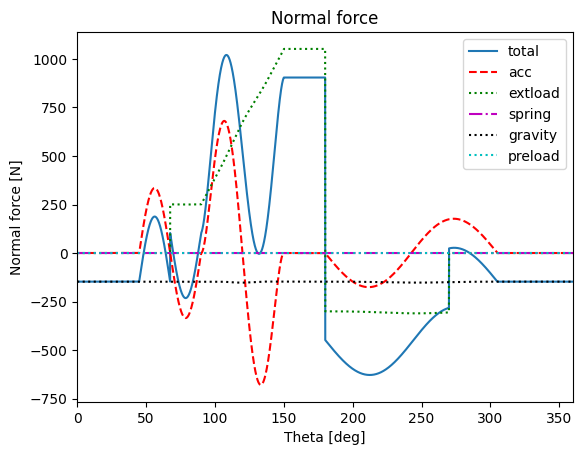

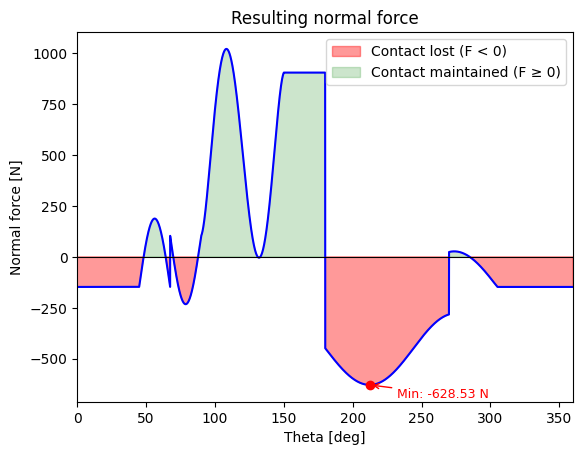

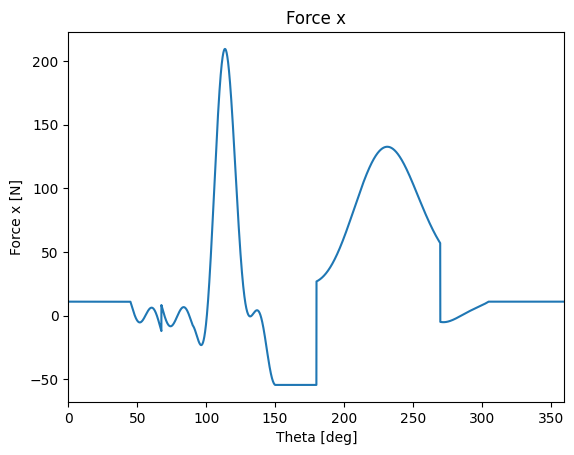

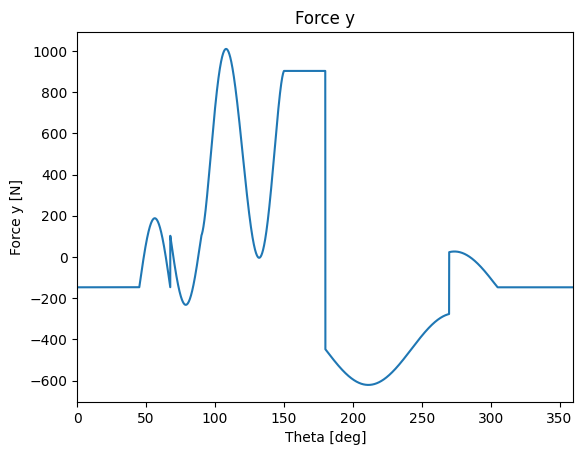

In [20]:
"""
Dit is een plot van de krachten als er geen preload is en de veerconstante 0 is, 
dus alleen de krachten door de massa en de externe belasting. Je ziet dat er een groot
deel van de beweging is waar de kracht negatief is, wat betekent dat er contactverlies is. 
Dit is natuurlijk niet wenselijk.
"""

# dynamic inputs
mass            =  15
spring_constant =  0# [N/mm]
spring_preload  = 0
rpm             = 200

# Calculate forces
[normalforce_tot1,normalforce_acc1,normalforce_load1,normalforce_spring1,force_x1,force_y1, gravity_force1, preload_force1] = calculateForce(rpm,lift,spring_constant,spring_preload,pressure_angle,ext_load,mass,acc)
# Plot forces
plotForces(theta_deg,normalforce_tot1,normalforce_acc1,normalforce_load1,normalforce_spring1,force_x1,force_y1, gravity_force1, preload_force1)

Due to gravity working at our disadvantage, a minimal neccesary preload is: 
$$ N(\theta = 0) = \frac{F_{v0} - mg \, \cos(\gamma)}{\cos(\alpha)} > 0 \Leftrightarrow F_{v0} > mg \, \cos(\gamma) $$
This leads to the first validation. Further, a trade off can be made to see if a stiff spring is enough to ensure contact during motion. The less preload, the better? A minimal preload is absolutely necessary to oppose the force of gravity. 

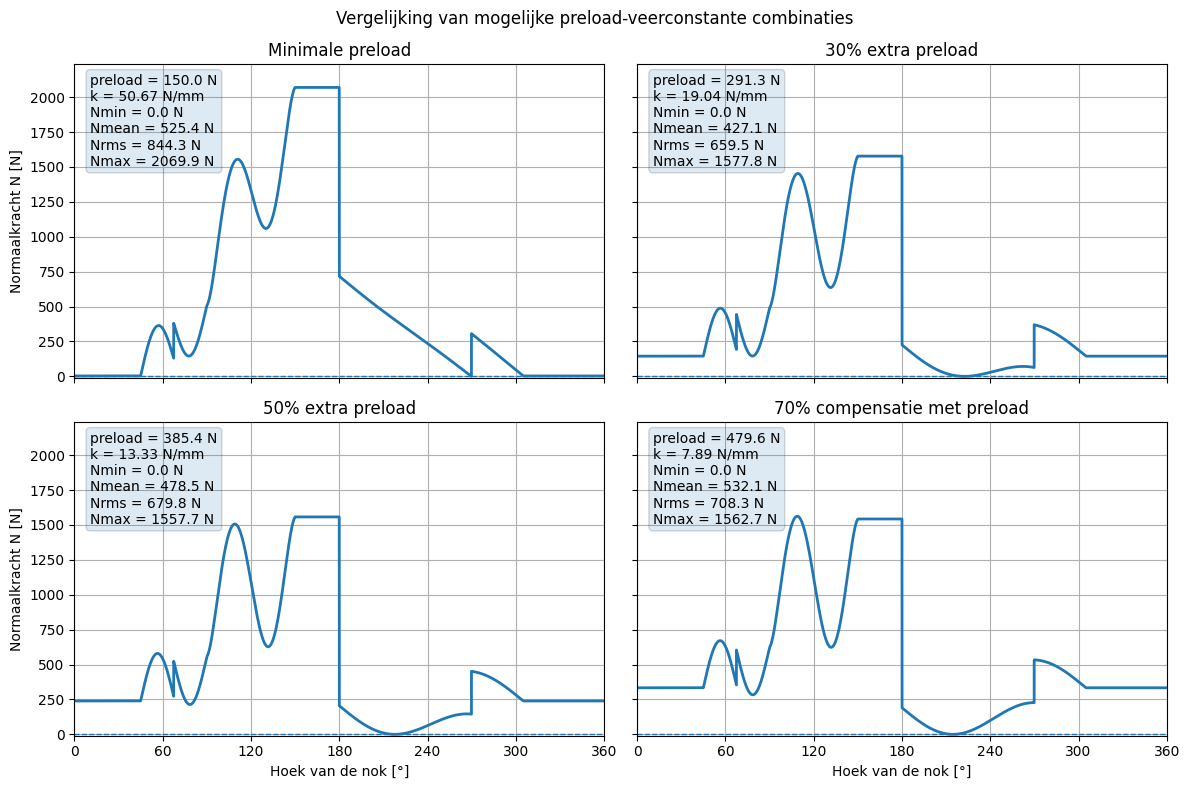

Gekozen veerontwerp
--------------------
Keuze:                 30% extra preload
spring_preload:        291.26 N
spring_constant:       19.04 N/mm
minimale normaalkracht: 0.00 N
gemiddelde normaalkracht: 427.05 N
piek-normaalkracht:    1577.84 N
rms-normaalkracht:     659.50 N

Referenties
-----------
Zonder preload/veer: minimale N = -628.53 N
Preload-only oplossing: preload = 620.87 N


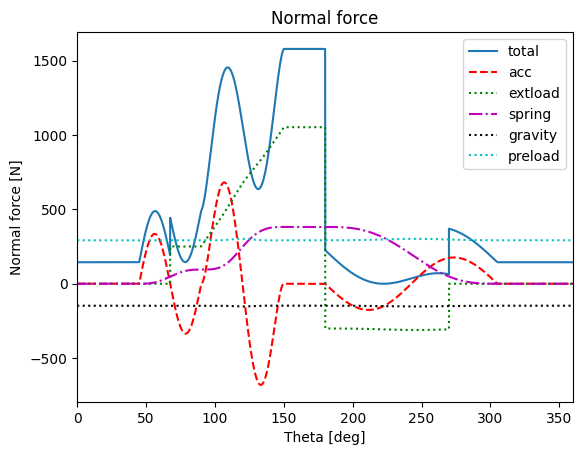

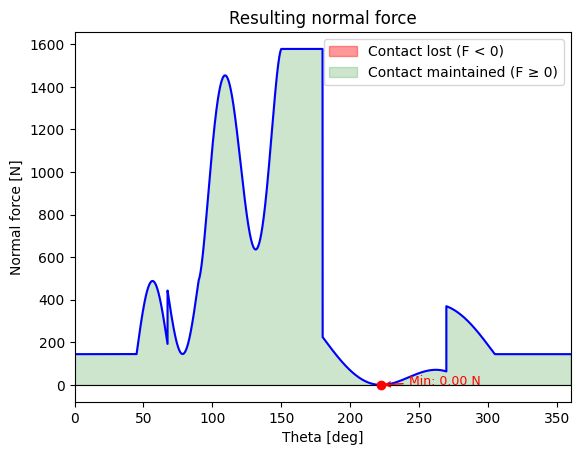

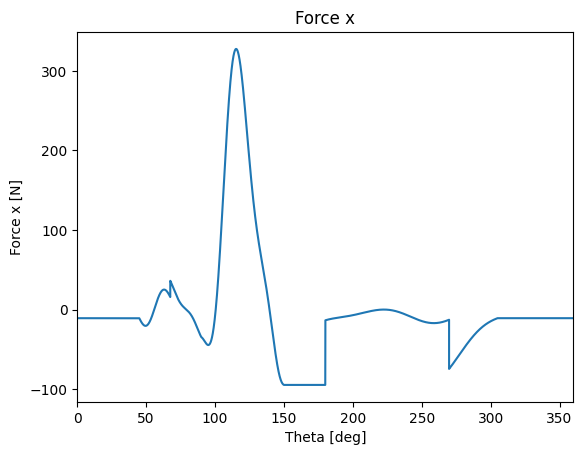

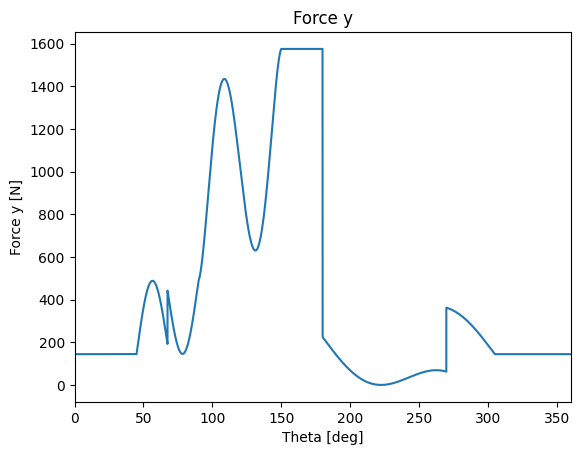

In [21]:
# ---------------------------------------------------------
# Spring design: preload-stiffness trade-off
# ---------------------------------------------------------
# Deze cel vervangt de oude manuele keuze van spring_preload en spring_constant.
# De rest van de notebook kan blijven werken omdat alle oude variabelen
# opnieuw worden aangemaakt: spring_constant, spring_preload,
# normalforce_tot, normalforce_tot1/2/3, force_x3, force_y3, ...

# Dynamic inputs
mass = 15        # kg, equivalente massa van volger en bijhorende onderdelen
rpm = 200        # rpm, rotatiesnelheid van de nok

# Design constraints
preload_min = 10 * mass   # N, afgeronde compensatie van de zwaartekracht: m*g ≈ 9.81*m
N_target = 0              # N, minimale toegelaten normaalkracht; 0 N = net geen loshechting
lift_eps = 1e-6           # mm, numerieke tolerantie om deling door nul bij lift = 0 te vermijden

omega = rpm * 2 * np.pi / 60
cos_alpha = np.cos(pressure_angle)

if np.any(cos_alpha <= 0):
    raise ValueError("De drukhoek is te groot: cos(alpha) wordt nul of negatief.")

# Krachtbijdrage in de teller van de normaalkracht zonder veer en zonder preload.
# De calculateForce-functie deelt deze teller achteraf door cos(alpha).
base_force_without_spring = (
    ext_load
    + mass * acc / 1000 * omega**2
    - mass * 9.81
)


def required_preload_for_k(k, N_target=0):
    """
    Berekent de minimale preload voor een gegeven veerconstante k,
    zodat N(theta) >= N_target over de volledige cyclus.
    """
    preload_required = N_target * cos_alpha - base_force_without_spring - k * lift
    return max(preload_min, np.max(preload_required))


def required_k_for_preload(preload, N_target=0):
    """
    Berekent de minimale veerconstante voor een gegeven preload,
    zodat N(theta) >= N_target over de volledige cyclus.

    Op punten waar lift = 0 kan de veerconstante niet helpen.
    Als daar de preload onvoldoende is, bestaat er geen eindige k-oplossing.
    """
    required_numerator = N_target * cos_alpha - base_force_without_spring - preload

    # Check punten waar de veer niet kan helpen omdat de lift nul is.
    mask_zero_lift = lift <= lift_eps
    if np.any(required_numerator[mask_zero_lift] > 1e-9):
        return np.inf

    # Voor punten met lift > 0 geldt: k >= required_numerator / lift
    mask_positive_lift = lift > lift_eps
    k_required_array = required_numerator[mask_positive_lift] / lift[mask_positive_lift]

    return max(0, np.max(k_required_array))


def evaluate_spring_case(label, preload):
    """
    Bepaalt voor één gekozen preload de minimale veerconstante,
    berekent de resulterende krachten en geeft samenvattende metrics terug.
    """
    k = required_k_for_preload(preload, N_target)

    if not np.isfinite(k):
        raise ValueError(
            f"Geen eindige veerconstante mogelijk voor '{label}'. "
            "De preload is onvoldoende op een punt waar lift = 0."
        )

    (
        normalforce_tot_case,
        normalforce_acc_case,
        normalforce_load_case,
        normalforce_spring_case,
        force_x_case,
        force_y_case,
        gravity_force_case,
        preload_force_case
    ) = calculateForce(
        rpm,
        lift,
        k,
        preload,
        pressure_angle,
        ext_load,
        mass,
        acc
    )

    return {
        "label": label,
        "preload": preload,
        "k": k,
        "normalforce_tot": normalforce_tot_case,
        "normalforce_acc": normalforce_acc_case,
        "normalforce_load": normalforce_load_case,
        "normalforce_spring": normalforce_spring_case,
        "force_x": force_x_case,
        "force_y": force_y_case,
        "gravity_force": gravity_force_case,
        "preload_force": preload_force_case,
        "N_min": np.min(normalforce_tot_case),
        "N_mean": np.mean(normalforce_tot_case),
        "N_rms": np.sqrt(np.mean(normalforce_tot_case**2)),
        "N_max": np.max(normalforce_tot_case),
    }


# ---------------------------------------------------------
# Referenties en voorbeeldontwerpen
# ---------------------------------------------------------

# Referentie zonder preload en zonder veer: toont hoe groot het loshechtingsprobleem is.
(
    normalforce_tot1,
    normalforce_acc1,
    normalforce_load1,
    normalforce_spring1,
    force_x1,
    force_y1,
    gravity_force1,
    preload_force1
) = calculateForce(
    rpm,
    lift,
    0,
    0,
    pressure_angle,
    ext_load,
    mass,
    acc
)

# Preload-only referentie: k = 0 en preload net groot genoeg om contact te behouden.
preload_only = required_preload_for_k(0, N_target)
(
    normalforce_tot2,
    normalforce_acc2,
    normalforce_load2,
    normalforce_spring2,
    force_x2,
    force_y2,
    gravity_force2,
    preload_force2
) = calculateForce(
    rpm,
    lift,
    0,
    preload_only,
    pressure_angle,
    ext_load,
    mass,
    acc
)

# Het verschil tussen de minimale preload en de preload-only oplossing
# wordt gebruikt om vier transparante ontwerpvoorbeelden te maken.
delta_preload = preload_only - preload_min

preload_fractions = [0.0, 0.3, 0.5, 0.7]
case_labels = [
    "Minimale preload",
    "30% extra preload",
    "50% extra preload",
    "70% compensatie met preload"
]

spring_design_cases = []
for label, fraction in zip(case_labels, preload_fractions):
    preload_case = preload_min + fraction * delta_preload
    spring_design_cases.append(evaluate_spring_case(label, preload_case))


# ---------------------------------------------------------
# Plot de vier voorbeeldontwerpen in één kader
# ---------------------------------------------------------

fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axs = axs.flatten()

N_global_max = max(case["N_max"] for case in spring_design_cases)
ymax = 1.08 * N_global_max

for ax, case in zip(axs, spring_design_cases):
    ax.plot(theta_deg, case["normalforce_tot"], linewidth=2)
    ax.axhline(N_target, linestyle="--", linewidth=1)
    ax.set_xlim(0, 360)
    ax.set_ylim(min(-10, 0.05 * ymax), ymax)
    ax.set_xticks(np.arange(0, 361, 60))
    ax.grid(True)

    info_text = (
        f"preload = {case['preload']:.1f} N\n"
        f"k = {case['k']:.2f} N/mm\n"
        f"Nmin = {case['N_min']:.1f} N\n"
        f"Nmean = {case['N_mean']:.1f} N\n"
        f"Nrms = {case['N_rms']:.1f} N\n"
        f"Nmax = {case['N_max']:.1f} N"
    )

    ax.text(
        0.03,
        0.97,
        info_text,
        transform=ax.transAxes,
        va="top",
        bbox=dict(boxstyle="round", alpha=0.15)
    )

    ax.set_title(case["label"])

for ax in axs[::2]:
    ax.set_ylabel("Normaalkracht N [N]")
for ax in axs[2:]:
    ax.set_xlabel("Hoek van de nok [°]")

fig.suptitle("Vergelijking van mogelijke preload-veerconstante combinaties")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Kies een transparant compromisontwerp
# ---------------------------------------------------------
# We kiezen hier bewust geen rigoureuze optimalisatie, maar een engineering compromis.
# Case 0 gebruikt minimale preload maar vereist de stijfste veer.
# Case 3 gebruikt meer preload en minder veerstijfheid, maar verhoogt de normaalkracht over de cyclus.
# Case 2 vormt een middenweg en wordt daarom verder gebruikt.

selected_case_index = 1   # 0=min preload, 1=30%, 2=50%, 3=70%
selected_case = spring_design_cases[selected_case_index]

spring_constant = selected_case["k"]
spring_preload = selected_case["preload"]

normalforce_tot = selected_case["normalforce_tot"]
normalforce_acc = selected_case["normalforce_acc"]
normalforce_load = selected_case["normalforce_load"]
normalforce_spring = selected_case["normalforce_spring"]
force_x = selected_case["force_x"]
force_y = selected_case["force_y"]
gravity_force = selected_case["gravity_force"]
preload_force = selected_case["preload_force"]

# Compatibiliteit met latere code uit het bestaande notebook.
# normalforce_tot3, force_x3 en force_y3 worden verder gebruikt als referentie
# voor de vergelijking met de geoptimaliseerde excentriciteit.
normalforce_tot3 = normalforce_tot
normalforce_acc3 = normalforce_acc
normalforce_load3 = normalforce_load
normalforce_spring3 = normalforce_spring
force_x3 = force_x
force_y3 = force_y
gravity_force3 = gravity_force
preload_force3 = preload_force

idx_min_force = np.argmin(normalforce_tot1)
displacement_at_min_force = lift[idx_min_force]

print("Gekozen veerontwerp")
print("--------------------")
print(f"Keuze:                 {selected_case['label']}")
print(f"spring_preload:        {spring_preload:.2f} N")
print(f"spring_constant:       {spring_constant:.2f} N/mm")
print(f"minimale normaalkracht: {np.min(normalforce_tot):.2f} N")
print(f"gemiddelde normaalkracht: {np.mean(normalforce_tot):.2f} N")
print(f"piek-normaalkracht:    {np.max(normalforce_tot):.2f} N")
print(f"rms-normaalkracht:     {np.sqrt(np.mean(normalforce_tot**2)):.2f} N")
print()
print("Referenties")
print("-----------")
print(f"Zonder preload/veer: minimale N = {np.min(normalforce_tot1):.2f} N")
print(f"Preload-only oplossing: preload = {preload_only:.2f} N")

# Detailplot van de gekozen oplossing met de bestaande plotfunctie.
plotForces(
    theta_deg,
    normalforce_tot,
    normalforce_acc,
    normalforce_load,
    normalforce_spring,
    force_x,
    force_y,
    gravity_force,
    preload_force
)


## Optimization of the excentricity without friction

The RMS contact force gets minimized to ensure minimal wear and fatigue

Optimal eccentricity (min RMS N): 7.00 mm
RMS normal force at optimum:      659.5 N


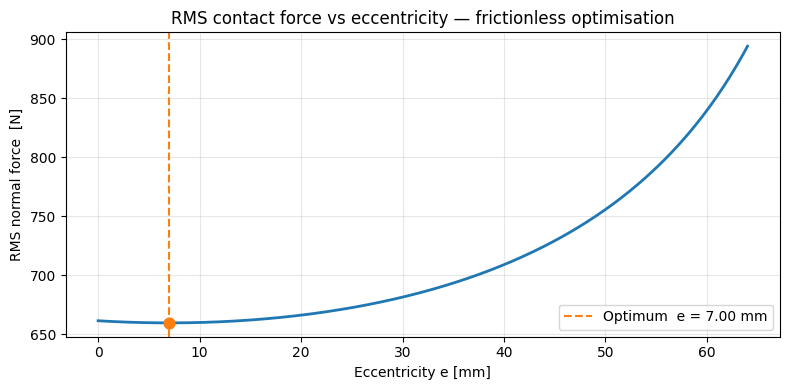

In [22]:
from scipy.optimize import minimize_scalar
import matplotlib.colors as mcolors

omega = rpm * 2 * np.pi / 60

F_num = (ext_load
         + spring_preload
         + spring_constant * lift
         + mass * (omega**2) * acc / 1000   # acc is in mm/rad², convert to m/rad²
         - mass * 9.81)

def rms_normal_force(exc_val):
    pa = calculatePressureAngle(vel, exc_val, base_radius, Rr, lift)
    N  = F_num / np.cos(pa)
    return np.sqrt(np.trapezoid(N**2, theta) / (2 * np.pi))

res = minimize_scalar(rms_normal_force,
                      bounds=(0, 0.8 * (base_radius + Rr)),
                      method='bounded')

exc_optimal_rms = res.x
N_rms_optimal   = res.fun

print(f"Optimal eccentricity (min RMS N): {exc_optimal_rms:.2f} mm")
print(f"RMS normal force at optimum:      {N_rms_optimal:.1f} N")

# --- Verification plot ---
exc_sweep = np.linspace(0, 0.8 * (base_radius + Rr), 300)
rms_sweep = np.array([rms_normal_force(e) for e in exc_sweep])

plt.figure(figsize=(8, 4))
plt.plot(exc_sweep, rms_sweep, color=list(mcolors.TABLEAU_COLORS.values())[0], lw=2)
plt.axvline(exc_optimal_rms, color=list(mcolors.TABLEAU_COLORS.values())[1],
            ls='--', lw=1.5, label=f'Optimum  e = {exc_optimal_rms:.2f} mm')
plt.scatter(exc_optimal_rms, N_rms_optimal,
            color=list(mcolors.TABLEAU_COLORS.values())[1], zorder=5, s=60)
plt.xlabel('Eccentricity e [mm]')
plt.ylabel('RMS normal force  [N]')
plt.title('RMS contact force vs eccentricity — frictionless optimisation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cam design with friction

In [23]:
def calculateForce_with_friction(rpm, lift, vel, spring_constant, spring_preload, pressure_angle, ext_load, mass, acc):
    mu = 0.1 # friction coefficient, assumed constant for simplicity
    omega = rpm*2*np.pi/60
    F_num = lift*spring_constant + spring_preload +  ext_load - mass*9.81 + mass*acc/1000*(omega**2)
    normalforce_tot = F_num / (np.cos(pressure_angle) - mu * np.abs(np.sin(pressure_angle))*np.sign(vel))
    friction_force = mu*np.abs(normalforce_tot*np.sin(pressure_angle))*np.sign(vel)
    force_x = normalforce_tot * np.sin(pressure_angle)
    force_y = normalforce_tot * np.cos(pressure_angle)

    return normalforce_tot, force_x,force_y, friction_force

def plotForces_with_friction(theta_deg, normalforce_tot, force_x, force_y, friction_force):
    plt.figure()
    plt.plot(theta_deg, normalforce_tot)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Normal force [N]')
    plt.xlim([0, 360])
    plt.title('Normal force')

    plt.figure()
    plt.plot(theta_deg, friction_force, ':c')
    plt.xlabel('Theta [deg]')
    plt.ylabel('friction force [N]')
    plt.xlim([0, 360])
    plt.title('Friction force')

    plt.figure()
    plt.plot(theta_deg, normalforce_tot, 'b')
    plt.axhline(y=0, color='k', linewidth=0.8)
    plt.fill_between(theta_deg, normalforce_tot, 0,
                     where=(normalforce_tot < 0),
                     color='red', alpha=0.4, label='Contact lost (F < 0)')
    plt.fill_between(theta_deg, normalforce_tot, 0,
                     where=(normalforce_tot >= 0),
                     color='green', alpha=0.2, label='Contact maintained (F ≥ 0)')

    # Indicate minimum value
    min_force = np.min(normalforce_tot)
    min_theta = theta_deg[np.argmin(normalforce_tot)]
    plt.annotate(f'Min: {min_force:.2f} N',
                 xy=(min_theta, min_force),
                 xytext=(min_theta + 20, min_force - 0.1 * abs(min_force)),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 color='red', fontsize=9)
    plt.scatter(min_theta, min_force, color='red', zorder=5)

    plt.xlabel('Theta [deg]')
    plt.ylabel('Normal force [N]')
    plt.xlim([0, 360])
    plt.legend()
    plt.title('Resulting normal force')

    plt.figure()
    plt.plot(theta_deg, force_x)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Force x [N]')
    plt.xlim([0, 360])
    plt.title('Force x')

    plt.figure()
    plt.plot(theta_deg, force_y)
    plt.xlabel('Theta [deg]')
    plt.ylabel('Force y [N]')
    plt.xlim([0, 360])
    plt.title('Force y')

## Optimization for the excentricity under friction force 

Optimalisatie voor excentriciteit en (steekcirkel R0). De doelfunctie houdt rekening met de arbeid dat geleverd wordt door de wrijvingskracht en een betere uitbalancering van de krachten. In de neergaande beweging mag de drukhoek groter zijn omdat deze beweging niet zo kritisch is voor de nauwkeurigheid van het proces. Een verhoging van de drukhoek in het tweede deel van de beweging lijdt tot een hogere kracht op de nok tijdens dat gedeelte van de beweging. Vermits de uitwendige kracht veel kleiner is en de beweging ook iets minder kritisch, is het gerechtvaardigd om alpha groter te maken tijdens dit deel van de beweging. 

Excentriciteit beinvloedt de drukhoek over het hele nokprofiel en daarmee ook de ongewenste wrijvingskracht. Om een optimale excentriciteit te bekomen wordt het vermogen geleverd door de wrijvingskracht geminimimaliseerd over 1 cyclus. Eventueel kan er een tweede term toegevoegd worden aan de functie die oplossingen met een hogere drukhoek aan de terugzijde bevoordeelt. Constraints die gelden zijn contact dat altijd behouden moeten worden en de drukhoek die kleiner moet zijn dan 35° over de hele beweging. 

To minimize the power dissipated by the friction force in the bore, the work by the friction force is calculated using: 
$$
\frac{W_{\mathrm{friction}}(e)}{\mu} = \int_{0}^{2\pi} |R| \left|\frac{dS}{d\theta}\right| \, d\theta = 
\int_{0}^{2\pi} F(\theta)\,\left|\tan\!\big(\alpha(\theta, e)\big)\right| \,\left|\frac{dS}{d\theta}\right| \, d\theta
$$
where

$$
F(\theta) = F_{\text{func}} + F_v + m \frac{d^2y}{dt^2} + m\, g\, \cos(\gamma)
$$

This function gets minimized in function of the excentricity e. Since the force is smaller for the returning part, the pressure angle will be automatically higher during this motion. Most of the gain will be made during this phase by increasing the pressure angle. This function takes several effects into an account. Firstly a high force and high velocity at the same interval should be avoided. To make sure of this a low pressure angle is required at these parts of the motion, for this a excentricity is necessary. If the excentricity is too high, the force during the returning motion will increase too much which leads to an increase in power dissipated. For too high excentricity values, the sign of alpha can switch and the pressure angle increases in the other direction. This leads to a rise in power and thus a high excentricity isn't desired.

Optimal eccentricity: 22.77 mm
Friction work at optimal e: 202.65 Nmm
Max α critical rise 45–180°: 16.5°
Max α return 180–305°:        25.6°
Minimum normal force:         0.00 N


<Figure size 640x480 with 0 Axes>

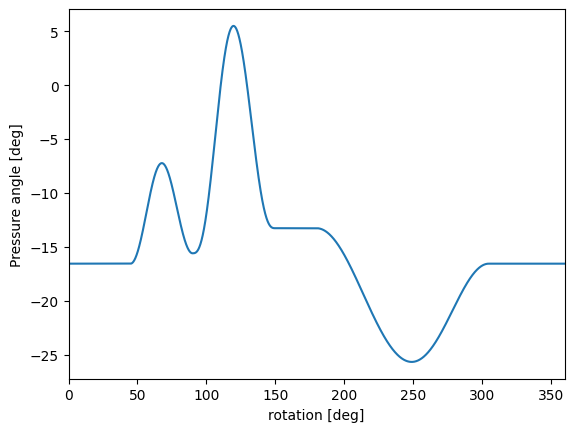

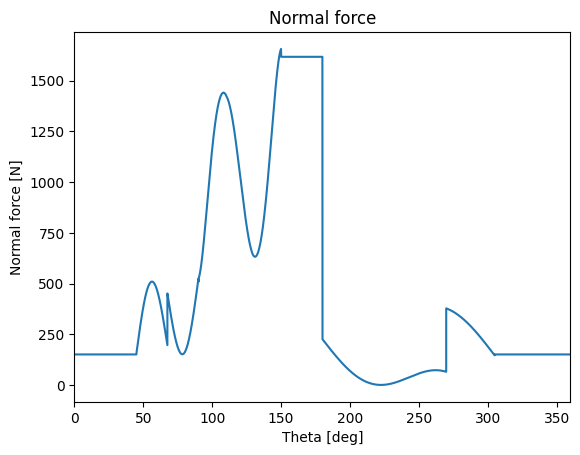

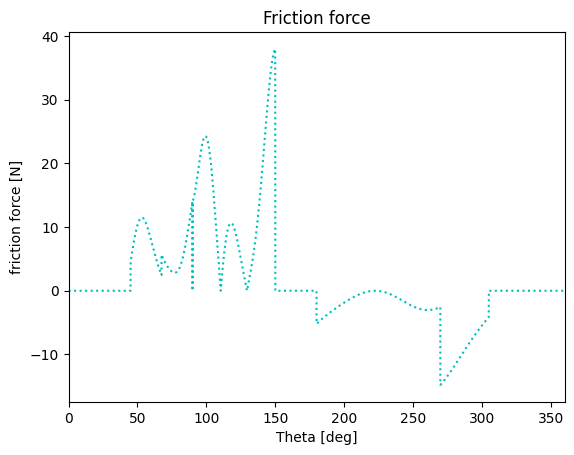

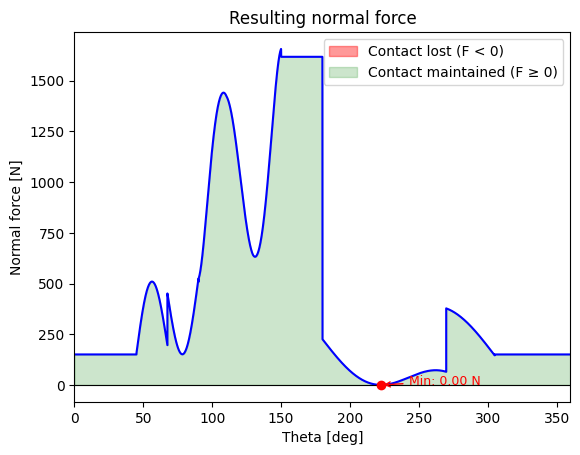

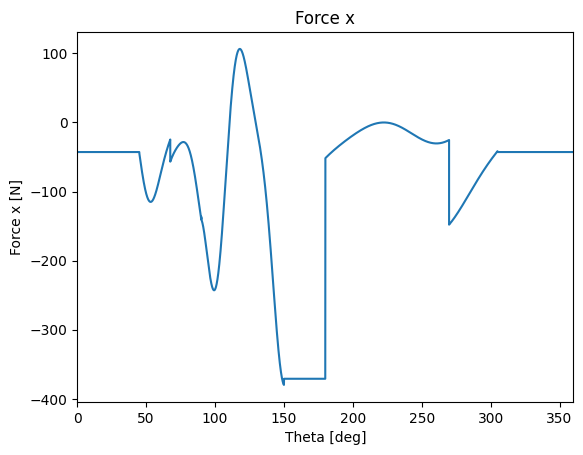

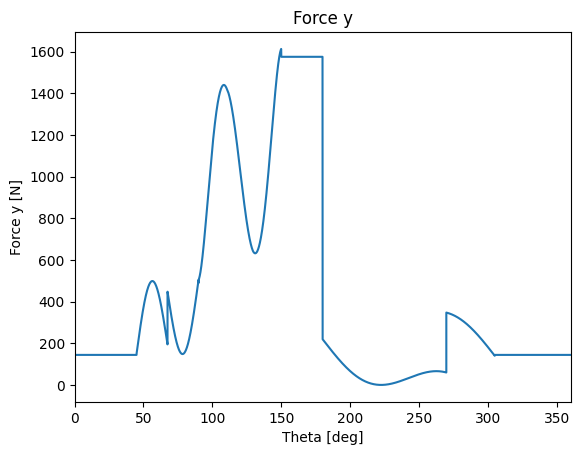

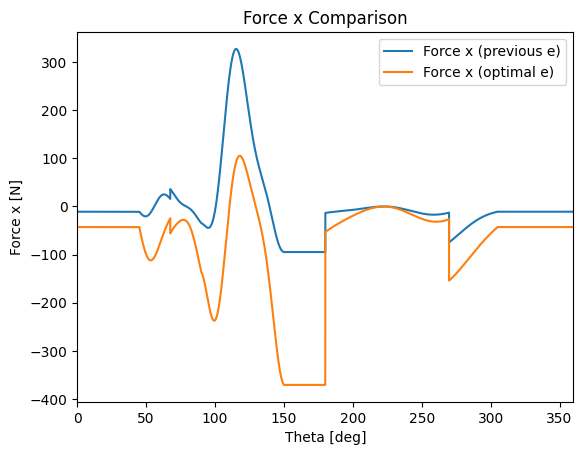

<Figure size 640x480 with 0 Axes>

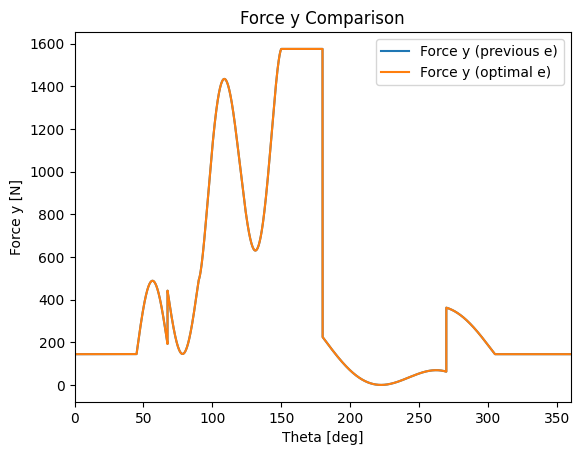

<Figure size 640x480 with 0 Axes>

In [24]:
# spring design
"""
# dynamic inputs
idx_min_force = np.argmin(normalforce_tot1)
displacement_at_min_force = lift[idx_min_force]
print(displacement_at_min_force)
mass            =  15
# spring_constant =  32 # [N/mm]
# spring_preload  = mass*9.81
rpm             = 200

# Calculate forces
[normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y, gravity_force, preload_force] = calculateForce(rpm,lift,spring_constant,spring_preload,pressure_angle,ext_load,mass,acc)
# Plot forces
plotForces(theta_deg,normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x ,force_y, gravity_force, preload_force)
"""
"""
from scipy.optimize import minimize_scalar

critical_mask = (theta_deg >= 45)  & (theta_deg <= 180)
return_mask   = (theta_deg >= 180) & (theta_deg <= 305)
omega = rpm * 2 * np.pi / 60

# F_num: independent of eccentricity (spring design is fixed)
F_num = (ext_load
         + spring_preload
         + spring_constant * lift
         + mass * (omega**2) * acc / 1000   # acc is in mm/rad², convert to m/rad²
         - mass * 9.81)

def friction_work(exc_val):
    pa = calculatePressureAngle(vel, exc_val, base_radius, Rr, lift)
    integrand = F_num * np.abs(np.tan(pa)) * np.abs(vel)
    return np.trapezoid(integrand, theta)  # theta in radians

# Only geometric bound: e must satisfy e < R0 for the square root to be real
e_max = 0.8 * (base_radius + Rr)  # conservative upper bound
result = minimize_scalar(friction_work, bounds=(0.0, e_max), method='bounded')

exc_optimal = result.x
print(f"Optimal eccentricity: {exc_optimal:.2f} mm")
print(f"Friction work at optimal e: {result.fun:.2f}  (N·mm/rad, proportional)")

# Verify pressure angle at optimal solution
pa_opt = calculatePressureAngle(vel, exc_optimal, base_radius, Rr, lift)
print(f"Max α (critical rise  45–180°): {np.max(np.abs(pa_opt[critical_mask]))*180/np.pi:.1f}°")
print(f"Max α (return 180–305°):        {np.max(np.abs(pa_opt[return_mask]))*180/np.pi:.1f}°")
"""
from scipy.optimize import minimize_scalar

critical_mask = (theta_deg >= 45)  & (theta_deg <= 180)
return_mask   = (theta_deg >= 180) & (theta_deg <= 305)

def friction_work(exc_val):
    pa = calculatePressureAngle(vel, exc_val, base_radius, Rr, lift)

    normalforce_tmp, force_x_tmp, force_y_tmp, friction_force_tmp = calculateForce_with_friction(
        rpm, lift, vel,
        spring_constant, spring_preload,
        pa, ext_load, mass, acc
    )

    # Contact mag niet verloren gaan
    if np.min(normalforce_tmp) < 0:
        return 1e12 + 1e9 * abs(np.min(normalforce_tmp))

    # Drukhoek moet onder 35 graden blijven
    if np.max(np.abs(pa)) > np.deg2rad(35):
        return 1e12 + 1e9 * (np.max(np.abs(pa)) - np.deg2rad(35))**2

    # Frictiewerk ~ integraal van |F_friction| * |dy/dtheta| dtheta
    # Eenheid is N*mm; delen door 1000 geeft J, maar voor optimalisatie maakt die schaal niet uit.
    integrand = np.abs(friction_force_tmp) * np.abs(vel)
    return np.trapezoid(integrand, theta)

e_max = 0.8 * R0

result = minimize_scalar(
    friction_work,
    bounds=(0.0, e_max),
    method="bounded"
)

exc_optimal = result.x
pressure_angle_opt = calculatePressureAngle(vel, exc_optimal, base_radius, Rr, lift)

normalforce_tot_opt, force_x_opt, force_y_opt, friction_force_opt = calculateForce_with_friction(
    rpm, lift, vel,
    spring_constant, spring_preload,
    pressure_angle_opt, ext_load, mass, acc
)

print(f"Optimal eccentricity: {exc_optimal:.2f} mm")
print(f"Friction work at optimal e: {result.fun:.2f} Nmm")
print(f"Max α critical rise 45–180°: {np.max(np.abs(pressure_angle_opt[critical_mask]))*180/np.pi:.1f}°")
print(f"Max α return 180–305°:        {np.max(np.abs(pressure_angle_opt[return_mask]))*180/np.pi:.1f}°")
print(f"Minimum normal force:         {np.min(normalforce_tot_opt):.2f} N")

plotPressureAngle(theta_deg, pressure_angle_opt)
plotForces_with_friction(theta_deg, normalforce_tot_opt, force_x_opt, force_y_opt, friction_force_opt)

# Calculate forces
[normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y, gravity_force, preload_force] = calculateForce(rpm,lift,spring_constant,spring_preload,pressure_angle_opt,ext_load,mass,acc)
# Plot forces
plt.figure()
plt.plot(theta_deg, force_x3, label='Force x (previous e)')
plt.plot(theta_deg, force_x, label='Force x (optimal e)')
plt.xlabel('Theta [deg]')
plt.ylabel('Force x [N]')
plt.xlim([0, 360])
plt.title('Force x Comparison')
plt.legend()
plt.figure()

plt.figure()
plt.plot(theta_deg, force_y3, label='Force y (previous e)')
plt.plot(theta_deg, force_y, label='Force y (optimal e)')
plt.xlabel('Theta [deg]')
plt.ylabel('Force y [N]')
plt.xlim([0, 360])
plt.title('Force y Comparison')
plt.legend()
plt.figure()



Raar bij de y kracht dat het verloop niet helemaal overeenkomt? Wordt vergeleken met de verkeerde waarde denk ik
Zou niet dezelfde waarde moeten geven bij nader inzien. Dit komt door de nieuwe uitdrukking van N

Visual check of the optimal excentricity which minimizes the work produced by the friction force. 

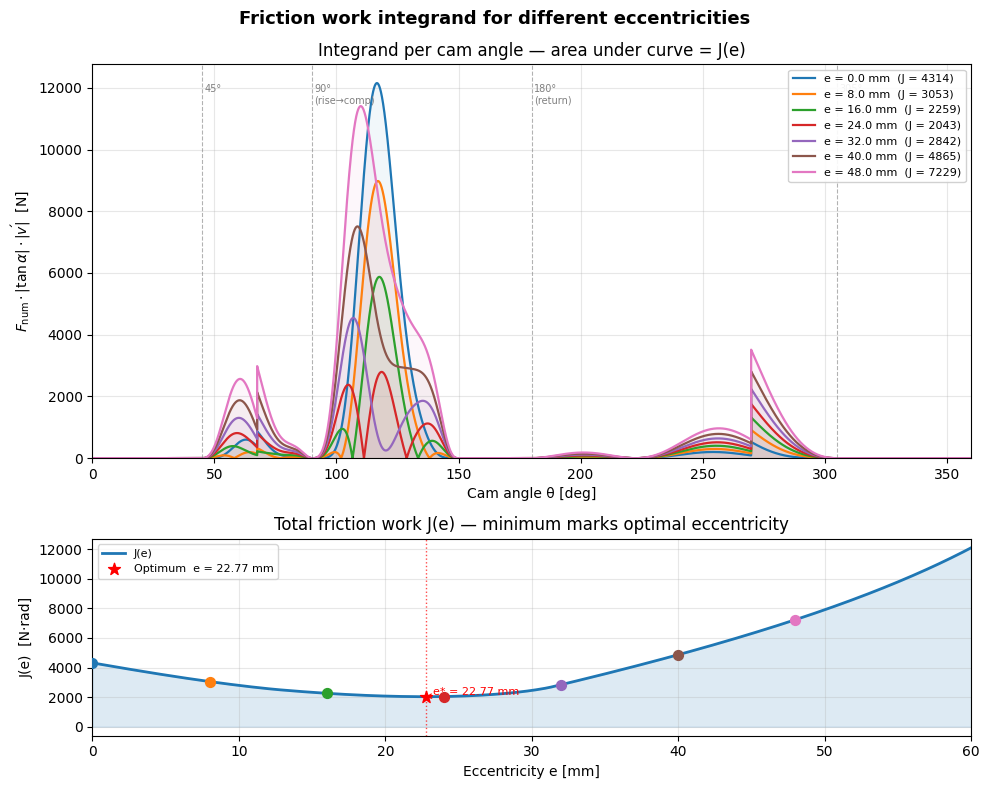

In [25]:
import matplotlib.colors as mcolors


def plot_friction_integrand_sweep(
        theta, vel, lift, acc,
        base_radius, Rr,
        ext_load, spring_preload, spring_constant,
        mass, rpm,
        exc_values=None,
        exc_optimal=None):
    """
    Plots the friction-work integrand  F_num * |tan(alpha)| * |vel|
    for a sweep of eccentricity values, plus the total J(e) curve.

    Parameters
    ----------
    exc_values   : list of eccentricities to overlay (mm). If None, a default
                   sweep from 0 to 0.6*R0 is used.
    exc_optimal  : the numerically found optimum to mark on the J(e) plot.
    """
    omega   = rpm * 2 * np.pi / 60
    theta_deg = np.degrees(theta)
    R0      = base_radius + Rr

    # --- F_num: independent of eccentricity ---
    F_num = (ext_load
             + spring_preload
             + spring_constant * lift
             + mass * omega**2 * acc / 1000   # acc mm/rad² → m/rad²
             - mass * 9.81)

    # Default sweep if not supplied
    if exc_values is None:
        exc_values = np.round(np.linspace(0, 0.6 * R0, 7), 1)

    # --- Compute J(e) over a fine grid for the bottom panel ---
    exc_fine = np.linspace(0, 0.75 * R0, 300)
    J_fine   = np.zeros_like(exc_fine)
    for i, e in enumerate(exc_fine):
        pa          = calculatePressureAngle(vel, e, base_radius, Rr, lift)
        integrand   = F_num * np.abs(np.tan(pa)) * np.abs(vel)
        J_fine[i]   = np.trapezoid(integrand, theta)

    # --- Figure layout ---
    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(10, 8),
        gridspec_kw={'height_ratios': [2, 1]})
    fig.suptitle('Friction work integrand for different eccentricities',
                 fontsize=13, fontweight='bold')

    colors = list(mcolors.TABLEAU_COLORS.values())[:len(exc_values)]


    # ── Top panel: integrand curves ────────────────────────────────────────
    for e, color in zip(exc_values, colors):
        pa        = calculatePressureAngle(vel, e, base_radius, Rr, lift)
        integrand = F_num * np.abs(np.tan(pa)) * np.abs(vel)
        J_val     = np.trapezoid(integrand, theta)
        ax_top.plot(theta_deg, integrand,
                    color=color, lw=1.6,
                    label=f'e = {e:.1f} mm  (J = {J_val:.0f})')
        ax_top.fill_between(theta_deg, integrand, alpha=0.06, color=color)

    # Mark phase boundaries
    for boundary, label in zip([45, 90, 180, 305],
                                ['45°', '90°\n(rise→comp)', '180°\n(return)', '305°']):
        ax_top.axvline(boundary, color='grey', lw=0.8, ls='--', alpha=0.6)
        ax_top.text(boundary + 1, ax_top.get_ylim()[1] * 0.95, label,
                    fontsize=7, color='grey', va='top')

    ax_top.set_xlabel('Cam angle θ [deg]')
    ax_top.set_ylabel(r'$F_\mathrm{num}\cdot|\tan\alpha|\cdot|v\'|$  [N]')
    ax_top.set_xlim([0, 360])
    ax_top.set_ylim(bottom=0)
    ax_top.legend(fontsize=8, loc='upper right', framealpha=0.9)
    ax_top.grid(True, alpha=0.3)
    ax_top.set_title('Integrand per cam angle — area under curve = J(e)')

    # ── Bottom panel: J(e) curve ───────────────────────────────────────────
    ax_bot.plot(exc_fine, J_fine, color=mcolors.TABLEAU_COLORS['tab:blue'], lw=2, label='J(e)')
    ax_bot.fill_between(exc_fine, J_fine, alpha=0.15, color=mcolors.TABLEAU_COLORS['tab:blue'])

    # Mark the sampled eccentricities as dots
    for e, color in zip(exc_values, colors):
        pa    = calculatePressureAngle(vel, e, base_radius, Rr, lift)
        J_dot = np.trapezoid(F_num * np.abs(np.tan(pa)) * np.abs(vel), theta)
        ax_bot.scatter(e, J_dot, color=color, zorder=5, s=50)

    # Mark the numerical optimum if provided
    if exc_optimal is not None:
        pa_opt  = calculatePressureAngle(vel, exc_optimal, base_radius, Rr, lift)
        J_opt   = np.trapezoid(F_num * np.abs(np.tan(pa_opt)) * np.abs(vel), theta)
        ax_bot.scatter(exc_optimal, J_opt,
                       color='red', zorder=6, s=80, marker='*',
                       label=f'Optimum  e = {exc_optimal:.2f} mm')
        ax_bot.axvline(exc_optimal, color='red', lw=1, ls=':', alpha=0.7)
        ax_bot.annotate(f'e* = {exc_optimal:.2f} mm',
                        xy=(exc_optimal, J_opt),
                        xytext=(exc_optimal + 0.5, J_opt * 1.05),
                        fontsize=8, color='red',
                        arrowprops=dict(arrowstyle='->', color='red', lw=0.8))

    ax_bot.set_xlabel('Eccentricity e [mm]')
    ax_bot.set_ylabel('J(e)  [N·rad]')
    ax_bot.set_xlim([0, exc_fine[-1]])
    ax_bot.legend(fontsize=8)
    ax_bot.grid(True, alpha=0.3)
    ax_bot.set_title('Total friction work J(e) — minimum marks optimal eccentricity')

    plt.tight_layout()
    plt.show()


# ── Call it ────────────────────────────────────────────────────────────────
plot_friction_integrand_sweep(
    theta, vel, lift, acc,
    base_radius, Rr,
    ext_load, spring_preload, spring_constant,
    mass, rpm,
    exc_values=None,   # adjust to your R0
    exc_optimal=exc_optimal                 # from minimize_scalar result
)

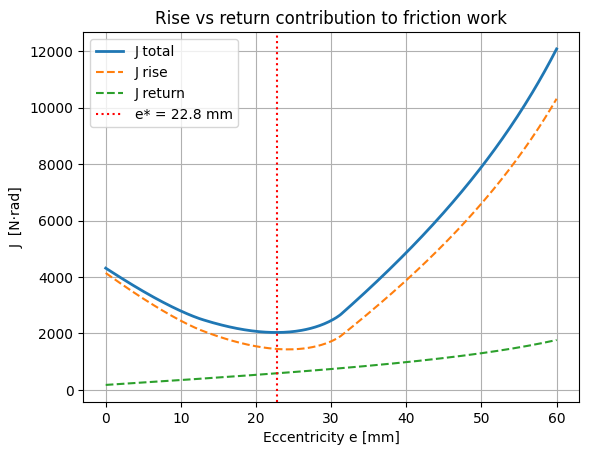

In [26]:
rise_mask   = (theta_deg >= 45)  & (theta_deg <= 180)
return_mask = (theta_deg >= 180) & (theta_deg <= 305)

exc_fine = np.linspace(0, 0.75 * R0, 300)

J_rise   = np.zeros_like(exc_fine)
J_return = np.zeros_like(exc_fine)

for i, e in enumerate(exc_fine):
    pa        = calculatePressureAngle(vel, e, base_radius, Rr, lift)
    integrand = F_num * np.abs(np.tan(pa)) * np.abs(vel)
    J_rise[i]   = np.trapezoid(integrand[rise_mask],   theta[rise_mask])
    J_return[i] = np.trapezoid(integrand[return_mask], theta[return_mask])

plt.figure()
plt.plot(exc_fine, J_rise + J_return, label='J total', lw=2)
plt.plot(exc_fine, J_rise,            label='J rise',   lw=1.5, ls='--')
plt.plot(exc_fine, J_return,          label='J return', lw=1.5, ls='--')
plt.axvline(exc_optimal, color='red', ls=':', label=f'e* = {exc_optimal:.1f} mm')
plt.xlabel('Eccentricity e [mm]')
plt.ylabel('J  [N·rad]')
plt.legend()
plt.grid(True)
plt.title('Rise vs return contribution to friction work')
plt.show()

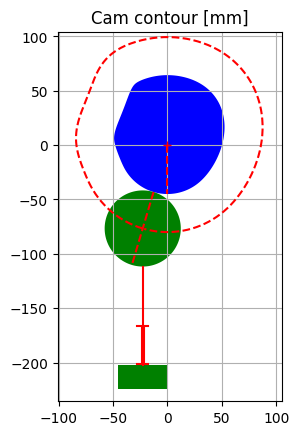

In [27]:
# Plot the cam contour
plotCamContour(base_radius,Rr,exc_optimal,theta,lift,pressure_angle_opt,dtheta)

# Power 


Firstly the power is calculated without any friction but with an excentricity. The formula for the power is given by:
$$
P(\theta) = (R(\theta) \times N(\theta)) \times \omega = N(\theta) \omega (e \cos(\alpha) + [\sqrt{R_0^2 - e^2} + f(\theta)] \sin(\alpha))
$$
if $ e = 0 $, then 
$$
P(\theta) = \omega N(\theta) \sin(\alpha) R(\theta)
$$

Average power with excentricity: 52.08 W


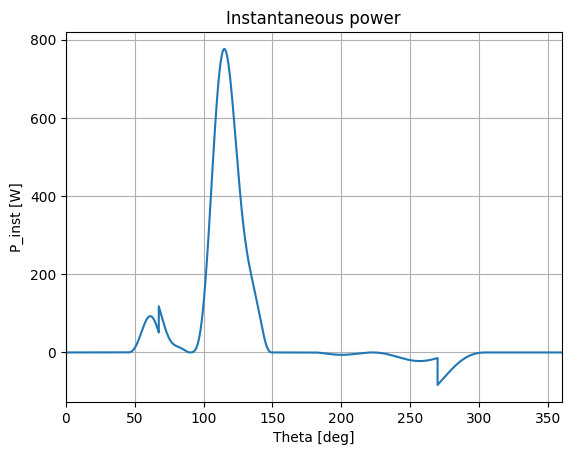

In [28]:
def calculateInstantaneousPower(rpm, pressure_angle, normalforce_tot, exc, lift, base_radius, follower_radius): # Calculate the instantanious power in Watt
    omega = rpm * 2 * np.pi / 60 # omega in rad/s
    e = exc * 10**(-3) # excentricity in m
    y = lift * 10**(-3) # lift in m
    Rb = base_radius * 10**(-3) # base radius in m
    Rf = follower_radius * 10**(-3) # follower radius in m
    P = omega * normalforce_tot * (np.cos(pressure_angle) * e + np.sin(pressure_angle) * (y + np.sqrt((Rb + Rf)**2 - e**2) ))
    return P

def calculateAveragePower(theta_deg, P, rpm):
    theta_rad = np.deg2rad(theta_deg)
    omega = rpm * 2 * np.pi / 60
    t = theta_rad / omega
    energy_cycle = np.trapezoid(P, t)
    T_cycle = (2*np.pi) / omega  # time for one full revolution = 2*pi/omega
    P_avg = energy_cycle / T_cycle
    return P_avg

def plotInstantaneousPower(theta_deg, P):
    plt.figure()
    plt.plot(theta_deg, P)
    plt.xlabel('Theta [deg]')
    plt.ylabel('P_inst [W]')
    plt.xlim([0,360])
    plt.grid()
    plt.title('Instantaneous power')

def differencePower(P, P0):
    P_diff = np.subtract(P, P0)
    return P_diff

def plotDifferencePower(theta_deg, P_diff):
    plt.figure()
    plt.plot(theta_deg, P_diff)
    plt.xlabel('Theta [deg]')
    plt.ylabel('P_diff [W]')
    plt.xlim([0,360])
    plt.grid()
    plt.title('Difference power')

# Calculate the instantanious power and average power with excentricity
pressure_angle = calculatePressureAngle(vel,exc , base_radius, Rr, lift)
[normalforce_tot,normalforce_acc,normalforce_load,normalforce_spring,force_x,force_y, gravity_force, preload_force] = calculateForce(rpm,lift,spring_constant,spring_preload,pressure_angle,ext_load,mass,acc)
instPower = calculateInstantaneousPower(rpm, pressure_angle, normalforce_tot, exc, lift, base_radius, Rr)
avgPower = calculateAveragePower(theta_deg, instPower, rpm)

plotInstantaneousPower(theta_deg, instPower)
print('Average power with excentricity:', "{0:0.2f}".format(round(avgPower, 2)), 'W')

The power is calculated with friction and the optimal excentricity value which minimizes the power generated by friction:
$$
P(\theta) =
\omega \,
\frac{
F_{\mathrm{ext}}(\theta)
}{
\cos\!\big(\alpha(\theta)\big)
-
\mu
\left|
\sin\!\big(\alpha(\theta)\big)
\right|
\,
\mathrm{sgn}\!\left(\frac{dS}{d\theta}\right)
}
\,
r_{\mathrm{eff}}(\theta)
$$

with

$$
r_{\mathrm{eff}}(\theta)
=
e \cos\!\big(\alpha(\theta)\big)
+
\sin\!\big(\alpha(\theta)\big)
\left(
f(\theta)
+
\sqrt{
R_0^2 - e^2
}
\right)
$$

Average power with friction and optimal eccentricity: 52.76 W
Peak instantaneous power: 781.72 W
Minimum instantaneous power: -79.65 W


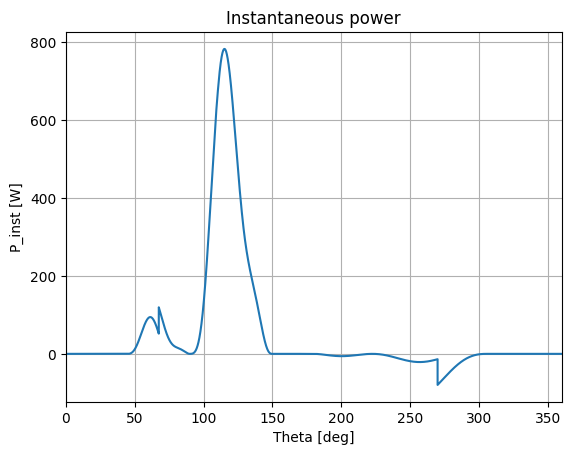

In [29]:
"""
def calculateInstantaneousPower_wf(rpm, pressure_angle, normalforce_tot, exc_optimal, lift, base_radius, follower_radius): # Calculate the instantanious power in Watt
    omega = rpm * 2 * np.pi / 60 # omega in rad/s
    e = exc_optimal * 10**(-3) # excentricity in m
    y = lift * 10**(-3) # lift in m
    Rb = base_radius * 10**(-3) # base radius in m
    Rf = follower_radius * 10**(-3) # follower radius in m
    P = omega * normalforce_tot * (np.cos(pressure_angle) * e + np.sin(pressure_angle) * (y + np.sqrt((Rb + Rf)**2 - e**2) ))
    return P


def calculateAveragePower(theta_deg, P, rpm):
    theta_rad = np.deg2rad(theta_deg)
    omega = rpm * 2 * np.pi / 60
    t = theta_rad / omega
    energy_cycle = np.trapezoid(P, t)
    T_cycle = (2*np.pi) / omega  # time for one full revolution = 2*pi/omega
    P_avg = energy_cycle / T_cycle
    return P_avg


def plotInstantaneousPower(theta_deg, P):
    plt.figure()
    plt.plot(theta_deg, P)
    plt.xlabel('Theta [deg]')
    plt.ylabel('P_inst [W]')
    plt.xlim([0,360])
    plt.grid()
    plt.title('Instantaneous power')


exc_values = np.round(np.linspace(0, 0.6 * R0, 7), 1)



instPower_wf = calculateInstantaneousPower(rpm, pa_opt, normalforce_tot_opt, exc_optimal, lift, base_radius, Rr)
avgPower = calculateAveragePower(theta_deg, instPower_wf, rpm)

plotInstantaneousPower(theta_deg, instPower_wf)
print('Average power with excentricity:', "{0:0.2f}".format(round(avgPower, 2)), 'W')
"""
# Power with friction and optimal eccentricity
# The same power formula is used; only the normal force now comes from the friction model.

instPower_wf = calculateInstantaneousPower(
    rpm,
    pressure_angle_opt,
    normalforce_tot_opt,
    exc_optimal,
    lift,
    base_radius,
    Rr
)

avgPower_wf = calculateAveragePower(theta_deg, instPower_wf, rpm)
peakPower_wf = np.max(instPower_wf)
minPower_wf = np.min(instPower_wf)

plotInstantaneousPower(theta_deg, instPower_wf)

print(f"Average power with friction and optimal eccentricity: {avgPower_wf:.2f} W")
print(f"Peak instantaneous power: {peakPower_wf:.2f} W")
print(f"Minimum instantaneous power: {minPower_wf:.2f} W")


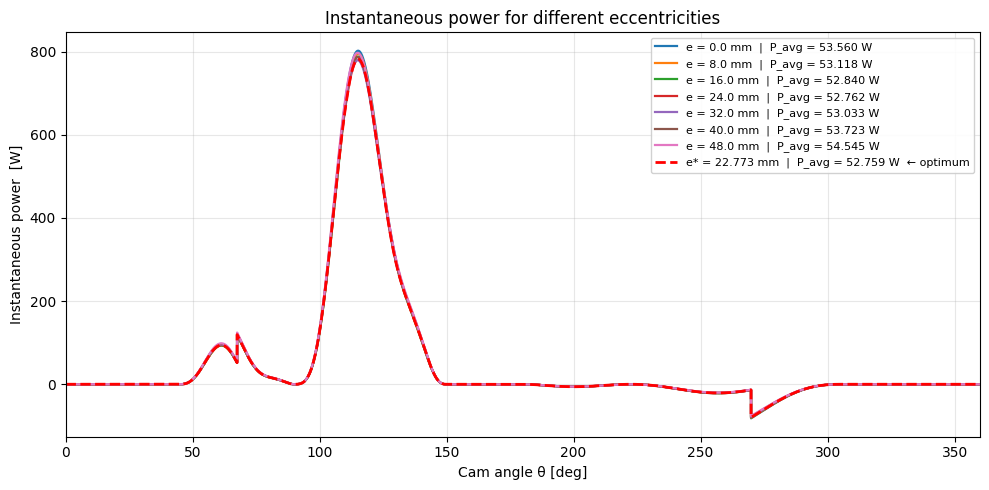

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = list(mcolors.TABLEAU_COLORS.values())

exc_values = np.round(np.linspace(0, 0.6 * R0, 7), 1)

for i, e in enumerate(exc_values):
    pa_e  = calculatePressureAngle(vel, e, base_radius, Rr, lift)
    [normalforce_tot_e, force_x,force_y, friction_force] = calculateForce_with_friction(rpm,lift, vel, spring_constant, spring_preload, pa_e, ext_load, mass, acc)
    P_e   = calculateInstantaneousPower(rpm, pa_e, normalforce_tot_e, e,
                                           lift, base_radius, Rr)
    P_avg = calculateAveragePower(theta_deg, P_e, rpm)

    ax.plot(theta_deg, P_e,
            color=colors[i % len(colors)], lw=1.6,
            label=f'e = {e:.1f} mm  |  P_avg = {P_avg:.3f} W')

# Mark the optimal eccentricity
pa_opt_ = calculatePressureAngle(vel, exc_optimal, base_radius, Rr, lift)
normalforce_tot_opt, force_x, force_y, friction_force = calculateForce_with_friction(
    rpm, lift, vel,
    spring_constant, spring_preload,
    pa_opt_,
    ext_load, mass, acc)

P_opt_  = calculateInstantaneousPower(rpm, pa_opt_, normalforce_tot_opt, exc_optimal,
                                          lift, base_radius, Rr)
P_avg_opt = calculateAveragePower(theta_deg, P_opt_, rpm)

ax.plot(theta_deg, P_opt_,
        color='red', lw=2, ls='--',
        label=f'e* = {exc_optimal:.3f} mm  |  P_avg = {P_avg_opt:.3f} W  ← optimum')

ax.set_xlabel('Cam angle θ [deg]')
ax.set_ylabel('Instantaneous power  [W]')
ax.set_title('Instantaneous power for different eccentricities')
ax.set_xlim([0, 360])
ax.legend(fontsize=8, loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()